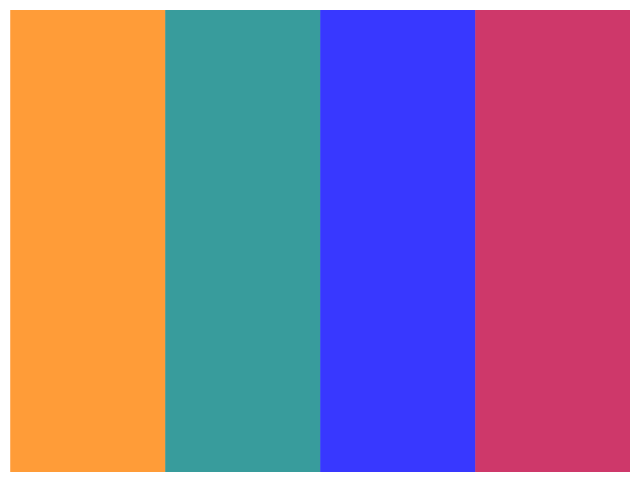

['amira', 'pdebench-comp', 'pdebench-incomp', 'pdegym-gauss', 'pdegym-sines', 'pdegym-sl', 'pdegym-svs', 'pdegym-pwc', 'pdegym-bb']


In [1]:
# read json file
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set up professional plotting style
rcParams.update({
    'font.size': 14,
    'figure.figsize': (8, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',

    # --- Lines & markers ---
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    "lines.markeredgewidth": 1,
    'lines.markerfacecolor': 'none',

    # Remove top/right spines globally
    'axes.spines.top': False,
    'axes.spines.right': False,

    "legend.frameon": False,
})
import matplotlib.colors as mcolors

#colors_hex = ["ffb56a", "6ab5b5", "6a6aff", "da6a8f"]
colors_hex = ["ff9c38", "389c9c", "3838ff", "ce386a", "ff9c38", "389c9c", "3838ff", "ce386a"]
colors_rgb = [mcolors.to_rgb(f"#{c}") for c in colors_hex]
colors = colors_rgb
# plot four colors
fig, ax = plt.subplots()
for i, color in enumerate(colors):
    ax.plot([i, i], [0, 1], color=color, linewidth=112)
# set limits and ticks off
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(0, 1)
ax.axis('off')
# save figure
#plt.savefig("color_palette.png", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

datasets_all = ["amira", "pdebench-comp", "pdebench-incomp", "pdegym-gauss", "pdegym-sines", "pdegym-sl", "pdegym-svs", "pdegym-pwc", "pdegym-bb"]
print(datasets_all)

In [2]:
error_type = "rae"  # or "rrmse"

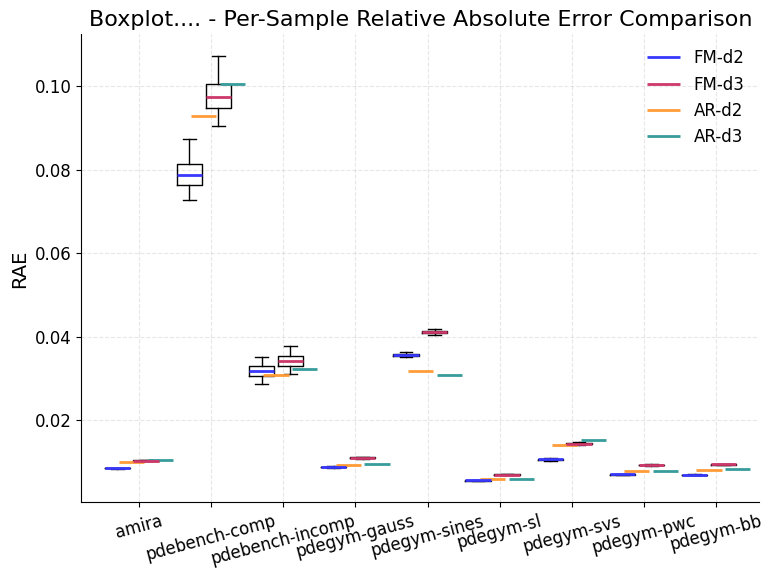

In [4]:
base_path_ar = "../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/ss_error/"
base_path_ar2 = "../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/ss_error/"
base_path_fm = "../../FluidGPT_validation/final_data/FM/fm-d2-9/ss_error/"
base_path_fm2 = "../../FluidGPT_validation/final_data/FM/fm-d3-6/ss_error/"

error_type_str = {"rae": "Per-Sample Relative Absolute Error", "rrmse": "Per-Sample Relative RMS Error"}
list_avg_ar = []
list_avg_ar2 = []
list_fm_data = []
list_fm_data2 = []
box_width = 0.35
offset = 0.2

for dataset_name in datasets_all:

    filename_ar = f"{base_path_ar}individual_{error_type}_{dataset_name}.json"
    filename_ar2 = f"{base_path_ar2}individual_{error_type}_{dataset_name}.json"
    filename_fm = f"{base_path_fm}individual_{error_type}_{dataset_name}.json"
    filename_fm2 = f"{base_path_fm2}individual_{error_type}_{dataset_name}.json"

    with open(filename_ar, "r") as f:
        data_ar = np.array(json.load(f))
    with open(filename_ar2, "r") as f:
        data_ar2 = np.array(json.load(f))
    with open(filename_fm, "r") as f:
        data_fm = np.array(json.load(f))
    with open(filename_fm2, "r") as f:
        data_fm2 = np.array(json.load(f))
    
    #data_ar = np.sort(data_ar)
    #data_ar2 = np.sort(data_ar2)
    data_fm = np.sort(data_fm)
    data_fm2 = np.sort(data_fm2)
    avg_ar = np.mean(data_ar, axis=0)
    avg_ar2 = np.mean(data_ar2, axis=0)
    avg_fm = np.mean(data_fm, axis=0)
    avg_fm2 = np.mean(data_fm2, axis=0)
    #print(f"Dataset: {dataset_name}, FM shape: {avg_fm.shape}, AR shape: {avg_ar.shape}")
    list_avg_ar.append(avg_ar)
    list_avg_ar2.append(avg_ar2)
    list_fm_data.append(avg_fm)
    list_fm_data2.append(avg_fm2)

fig, ax = plt.subplots()
bp = ax.boxplot(list_fm_data, widths=box_width, positions=np.arange(1, len(datasets_all) + 1) - 1.5 * offset, label="FM-d2")

# Plot the second boxplot (FM-d2-9) beside the first one
bp2 = ax.boxplot(list_fm_data2, widths=box_width, positions=np.arange(1, len(datasets_all) + 1) + 0.5 * offset, label="FM-d3")

for i, item in enumerate(list_avg_ar):
    x_center = i + 1
    y_ref = item
    ax.hlines(
        y=y_ref,
        xmin=x_center - box_width / 2 - 0.5 * offset,
        xmax=x_center + box_width / 2 - 0.5 * offset,
        linewidth=2,
        color=colors[0], 
        label="AR-d2" if i == 0 else None
    )
for i, item in enumerate(list_avg_ar2):
    x_center = i + 1
    y_ref = item
    ax.hlines(
        y=y_ref,
        xmin=x_center - box_width / 2 + 1.5 * offset,
        xmax=x_center + box_width / 2 + 1.5 * offset,
        linewidth=2,
        color=colors[1],
        label="AR-d3" if i == 0 else None
    )
for median in bp["medians"]:
    median.set(color=colors[2], linewidth=2)
for median in bp2["medians"]:
    median.set(color=colors[3], linewidth=2)
# put the datasetname at the x-axis
ax.set_xticks(np.arange(1, len(datasets_all) + 1))
ax.set_xticklabels(datasets_all, rotation=15)
ax.set_ylabel(f"{error_type.upper()}")
ax.set_title(f"Boxplot.... - {error_type_str[error_type]} Comparison")
#ax.set_ylim(0, 0.11)
ax.legend()
plt.tight_layout()

#plt.savefig(f"../../report/figs/results/ssbox_{error_type}.png", dpi=300)
#plt.savefig(f"../../../FluidGPT_validation/ssbox_{error_type}.png", dpi=300)
plt.show()

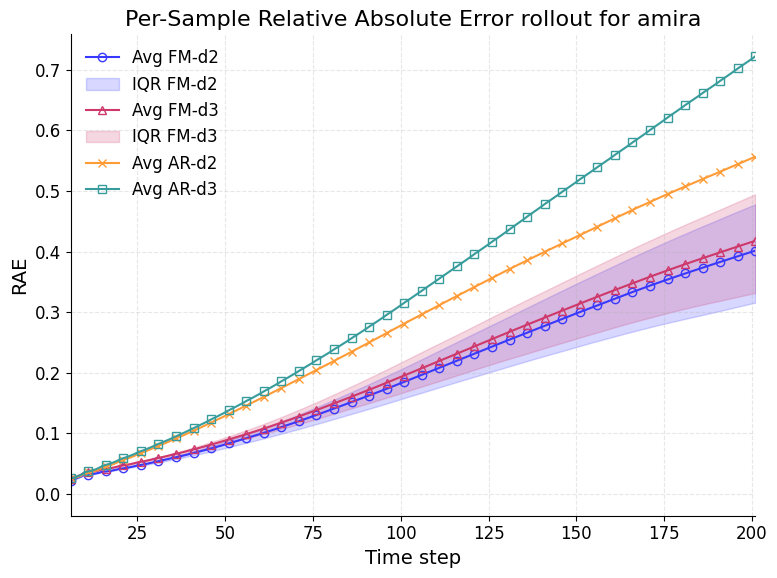

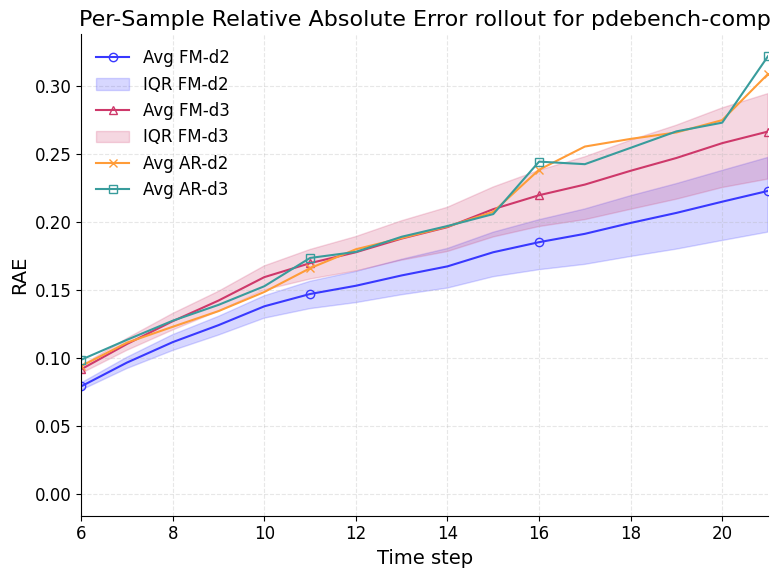

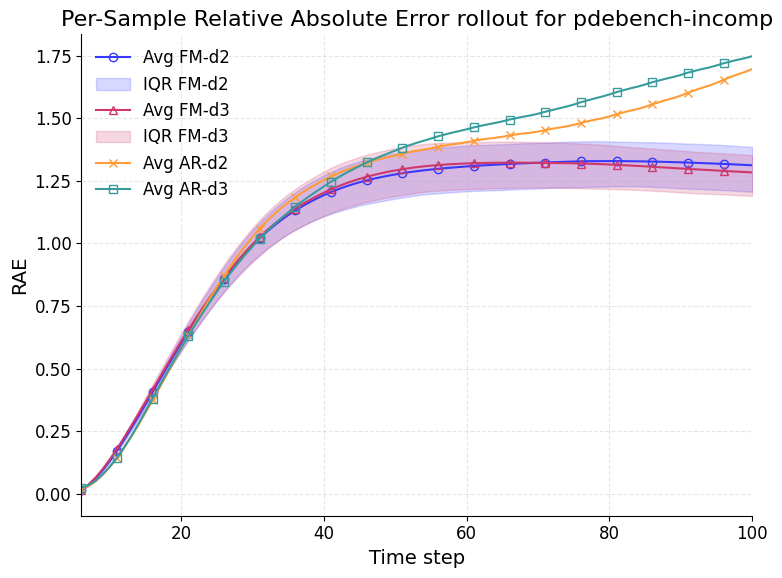

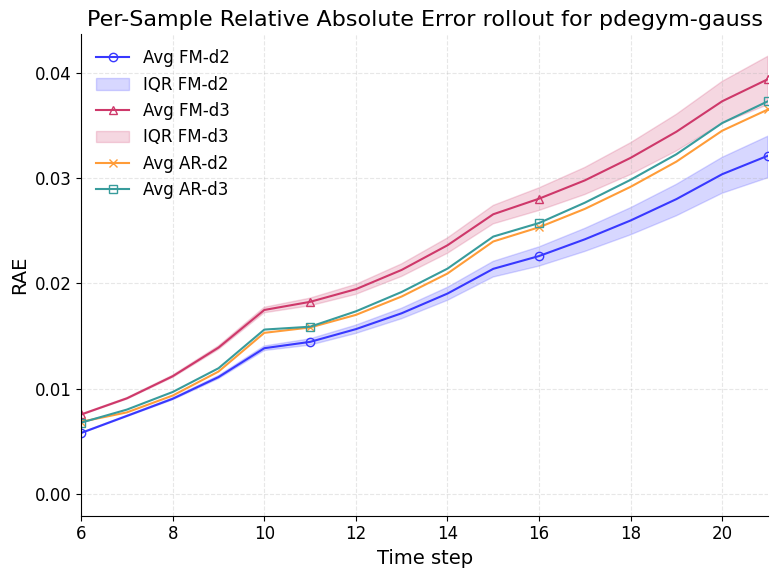

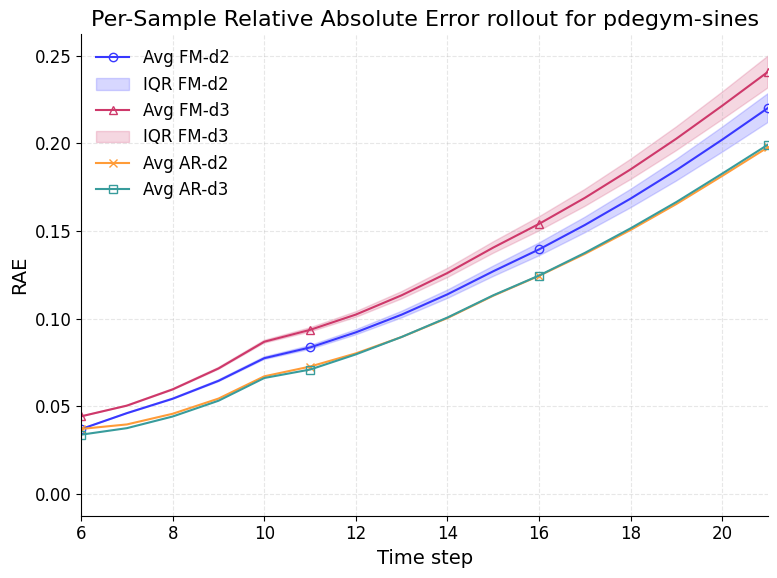

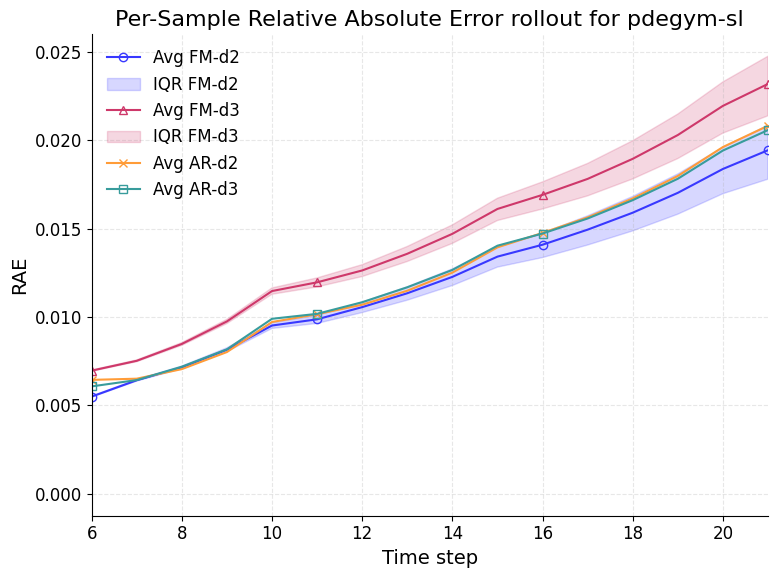

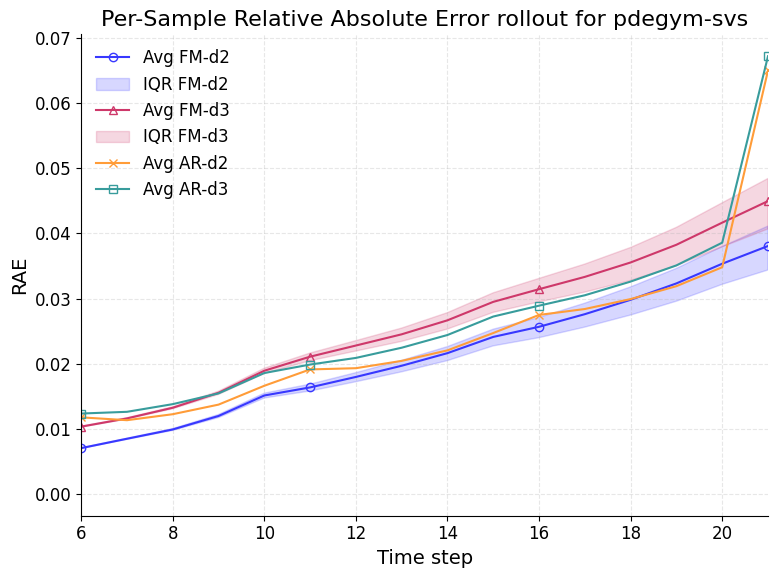

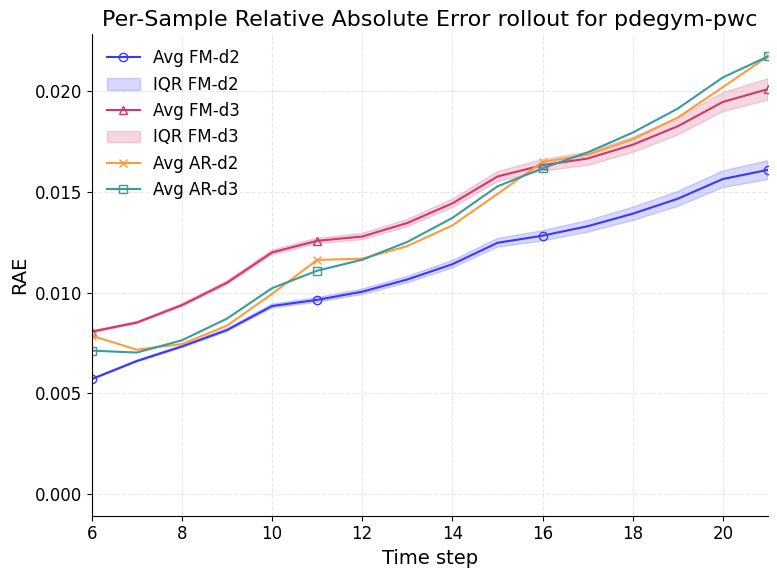

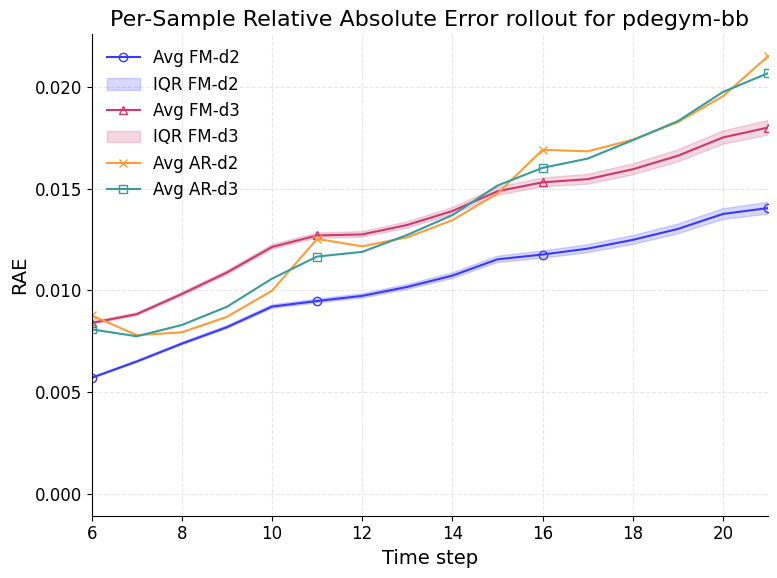

In [6]:
base_path_ar = "../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/ms_error/"
base_path_ar2 = "../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/ms_error/"
base_path_fm = "../../FluidGPT_validation/final_data/FM/fm-d2-9/ms_error/"
base_path_fm2 = "../../FluidGPT_validation/final_data/FM/fm-d3-6/ms_error/"

tb = 5
linealpha = 1
distralpha = 0.2
linewidth = 1.5

for dataset_name in datasets_all:

    filename_ar = f"{base_path_ar}individual_rollout_{error_type}_{dataset_name}.json"
    filename_ar2 = f"{base_path_ar2}individual_rollout_{error_type}_{dataset_name}.json"
    filename_fm = f"{base_path_fm}individual_rollout_{error_type}_{dataset_name}.json"
    filename_fm2 = f"{base_path_fm2}individual_rollout_{error_type}_{dataset_name}.json"

    with open(filename_ar, "r") as f:
        data_ar = np.array(json.load(f))
    with open(filename_ar2, "r") as f:
        data_ar2 = np.array(json.load(f))
    with open(filename_fm, "r") as f:
        data_fm = np.array(json.load(f))
    with open(filename_fm2, "r") as f:
        data_fm2 = np.array(json.load(f))

    fig, ax = plt.subplots()
    #print(f"data_fm shape: {data_fm.shape}, data_ar shape: {data_ar.shape}")
    avg_fm = np.mean(data_fm, axis=(1,2))
    avg_fm2 = np.mean(data_fm2, axis=(1,2))
    avg_ar = np.mean(data_ar, axis=1)
    avg_ar2 = np.mean(data_ar2, axis=1)
    #print(f"avg_fm shape: {avg_fm.shape}, avg_ar shape: {avg_ar.shape}")
    q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=(2))
    q0_2, q25_2, q50_2, q75_2, q100_2 = np.quantile(data_fm2, [0, 0.25, 0.5, 0.75, 1], axis=(2))
    #compute the mean of the quantiles over axis 1
    q0 = np.mean(q0, axis=1)
    q25 = np.mean(q25, axis=1)
    q50 = np.mean(q50, axis=1)
    q75 = np.mean(q75, axis=1)
    q100 = np.mean(q100, axis=1)
    q0_2 = np.mean(q0_2, axis=1)
    q25_2 = np.mean(q25_2, axis=1)
    q50_2 = np.mean(q50_2, axis=1)
    q75_2 = np.mean(q75_2, axis=1)
    q100_2 = np.mean(q100_2, axis=1)
    xspace = np.arange(1, data_ar.shape[0]+1)
    ax.plot(xspace, avg_fm, 'o-', color=colors[2], alpha=linealpha, label='Avg FM-d2', markevery=5, linewidth=linewidth)
    plt.fill_between(xspace, q25, q75, color=colors[2], alpha=distralpha, label='IQR FM-d2')
    ax.plot(xspace, avg_fm2, '^-', color=colors[3], alpha=linealpha, label='Avg FM-d3', markevery=5, linewidth=linewidth)
    plt.fill_between(xspace, q25_2, q75_2, color=colors[3], alpha=distralpha, label='IQR FM-d3')
    ax.plot(xspace, avg_ar, 'x-', color=colors[0], alpha=linealpha, label='Avg AR-d2', markevery=5, linewidth=linewidth)
    ax.plot(xspace, avg_ar2, 's-', color=colors[1], alpha=linealpha, label='Avg AR-d3', markevery=5, linewidth=linewidth)

    ax.set_xlabel("Time step")
    ax.set_ylabel(f"{error_type.upper()}")
    ax.set_title(f"{error_type_str[error_type]} rollout for {dataset_name}")
    ax.legend(loc='upper left') 
     
    ax.set_xlim(6, data_ar.shape[0])
    plt.tight_layout()
    #plt.savefig(f"../../report/figs/results/msgraph_{dataset_name}_{error_type}.png", dpi=300)
    #plt.savefig(f"../../../FluidGPT_validation/msgraph_{dataset_name}_{error_type}.png", dpi=300)
    plt.show()

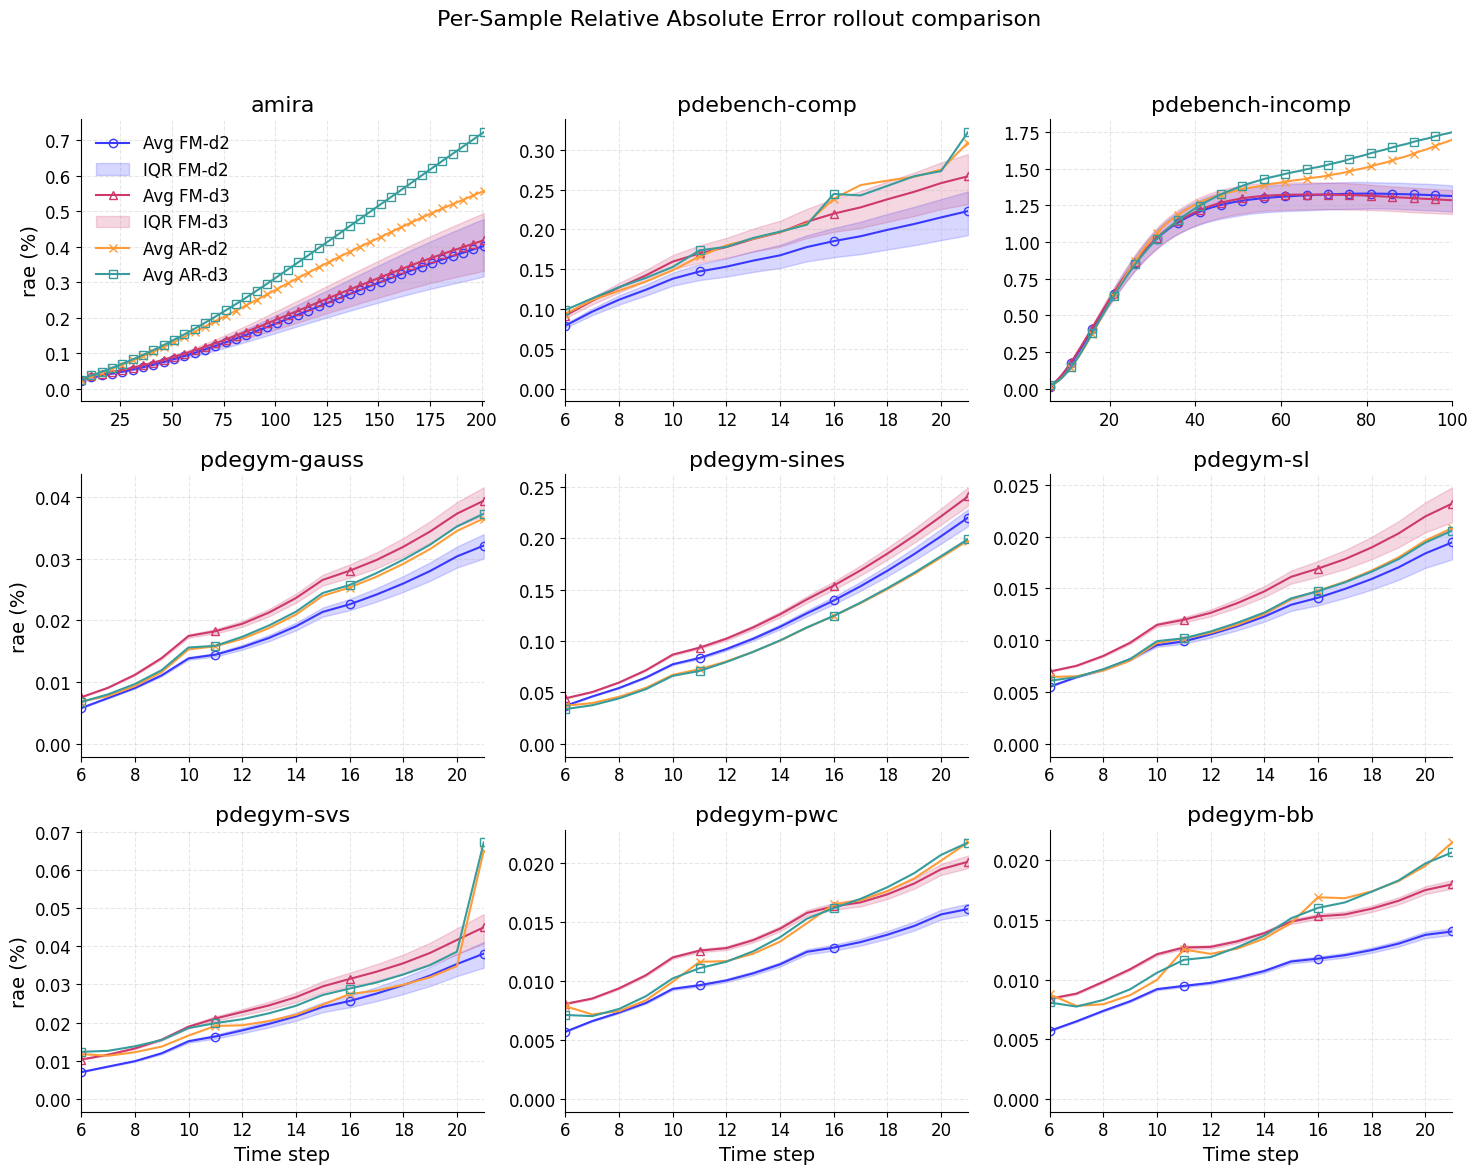

In [ ]:
base_path_ar = "../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/ms_error/"
base_path_ar2 = "../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/ms_error/"
base_path_fm = "../../FluidGPT_validation/final_data/FM/fm-d2-9/ms_error/"
base_path_fm2 = "../../FluidGPT_validation/final_data/FM/fm-d3-6/ms_error/"
error_type_str = {"rae": "Per-Sample Relative Absolute Error", "rrmse": "Per-Sample Relative RMS Error"}

tb = 5
linealpha = 1
distralpha = 0.2
linewidth = 1.5

# --------------------------------------------------
# Create 3x3 summary figure (for first 9 datasets)
# --------------------------------------------------
fig_all, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, dataset_name in enumerate(datasets_all):

    filename_ar = f"{base_path_ar}individual_rollout_{error_type}_{dataset_name}.json"
    filename_ar2 = f"{base_path_ar2}individual_rollout_{error_type}_{dataset_name}.json"
    filename_fm = f"{base_path_fm}individual_rollout_{error_type}_{dataset_name}.json"
    filename_fm2 = f"{base_path_fm2}individual_rollout_{error_type}_{dataset_name}.json"

    with open(filename_ar, "r") as f:
        data_ar = np.array(json.load(f))
    with open(filename_ar2, "r") as f:
        data_ar2 = np.array(json.load(f))
    with open(filename_fm, "r") as f:
        data_fm = np.array(json.load(f))
    with open(filename_fm2, "r") as f:
        data_fm2 = np.array(json.load(f))

    avg_fm = np.mean(data_fm, axis=(1,2))
    avg_fm2 = np.mean(data_fm2, axis=(1,2))
    avg_ar = np.mean(data_ar, axis=1)
    avg_ar2 = np.mean(data_ar2, axis=1)

    q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=2)
    q0_2, q25_2, q50_2, q75_2, q100_2 = np.quantile(data_fm2, [0, 0.25, 0.5, 0.75, 1], axis=2)

    q25 = np.mean(q25, axis=1)
    q75 = np.mean(q75, axis=1)
    q25_2 = np.mean(q25_2, axis=1)
    q75_2 = np.mean(q75_2, axis=1)

    xspace = np.arange(1, data_ar.shape[0] + 1)

    # ==================================================
    # Individual figure (UNCHANGED BEHAVIOR)
    # ==================================================
    fig, ax = plt.subplots()

    ax.plot(xspace, avg_fm, 'o-', color=colors[2], alpha=linealpha,
            label='Avg FM-d2', markevery=5, linewidth=linewidth)
    ax.fill_between(xspace, q25, q75, color=colors[2], alpha=distralpha)

    ax.plot(xspace, avg_fm2, '^-', color=colors[3], alpha=linealpha,
            label='Avg FM-d3', markevery=5, linewidth=linewidth)
    ax.fill_between(xspace, q25_2, q75_2, color=colors[3], alpha=distralpha)

    ax.plot(xspace, avg_ar, 'x-', color=colors[0], alpha=linealpha,
            label='Avg AR-d2', markevery=5, linewidth=linewidth)

    ax.plot(xspace, avg_ar2, 's-', color=colors[1], alpha=linealpha,
            label='Avg AR-d3', markevery=5, linewidth=linewidth)

    ax.set_xlabel("Time step")
    ax.set_ylabel(f"{error_type.upper()}")
    ax.set_title(f"{error_type_str[error_type]} rollout for {dataset_name}")
    ax.legend(loc='upper left')
    ax.set_xlim(6, data_ar.shape[0])

    plt.tight_layout()
    #plt.savefig(f"../../report/figs/results/msgraph_{dataset_name}_{error_type}.png", dpi=300)
    #plt.savefig(f"../../../FluidGPT_validation/msgraph_{dataset_name}_{error_type}.png", dpi=300)
    plt.close(fig)

    # ==================================================
    # Add to 3x3 combined figure (first 9 datasets)
    # ==================================================
    if idx < 9:
        ax_all = axes[idx]

        ax_all.plot(xspace, avg_fm, 'o-', markevery=5, color=colors[2], alpha=linealpha, linewidth=linewidth, label='Avg FM-d2')
        ax_all.fill_between(xspace, q25, q75, color=colors[2], alpha=distralpha, label='IQR FM-d2')

        ax_all.plot(xspace, avg_fm2, '^-', markevery=5, color=colors[3], alpha=linealpha, linewidth=linewidth, label='Avg FM-d3')
        ax_all.fill_between(xspace, q25_2, q75_2, color=colors[3], alpha=distralpha, label='IQR FM-d3')

        ax_all.plot(xspace, avg_ar, 'x-', markevery=5, color=colors[0], alpha=linealpha, linewidth=linewidth, label='Avg AR-d2')
        ax_all.plot(xspace, avg_ar2, 's-', markevery=5, color=colors[1], alpha=linealpha, linewidth=linewidth, label='Avg AR-d3')
        ax_all.set_title(dataset_name)
        ax_all.set_xlim(6, data_ar.shape[0])

        if idx % 3 == 0:
            ax_all.set_ylabel(f"{error_type} (%)")
        if idx >= 6:
            ax_all.set_xlabel("Time step")

# --------------------------------------------------
# Finalize and save combined figure
# --------------------------------------------------
axes[0].legend(loc='upper left')
fig_all.suptitle(f"{error_type_str[error_type]} rollout comparison", fontsize=16)
fig_all.tight_layout(rect=[0, 0, 1, 0.96])

#fig_all.savefig(f"../../report/figs/results/msgraph_all_{error_type}.png", dpi=300)
#fig_all.savefig(f"../../../FluidGPT_validation/msgraph_all_{error_type}.png", dpi=300)

plt.show()

ar: [  0.99587663   1.01083648   0.9895736    1.17521956   2.32765073
  22.69161655  14.85377993  44.25243416 359.25829997  75.34466771]
q50: [  1.00139914   1.00030048   0.99322454   0.98775439   1.19188782
   5.12378434   3.94622228  12.40554329 133.74071858  70.53225366]
(64,) (64,) (64,)
ar: [9.99414025e-01 1.01345596e+00 9.99281938e-01 1.02112548e+00
 1.35973342e+00 1.14667122e+01 4.01473761e+00 1.80291227e+01
 6.52126287e+03 3.46826337e+01]
q50: [  0.99972716   1.00675039   1.00001257   1.00020481   1.10245254
   2.01083623   1.55434241   4.47060574 986.74119865  28.1835578 ]
(64,) (64,) (64,)


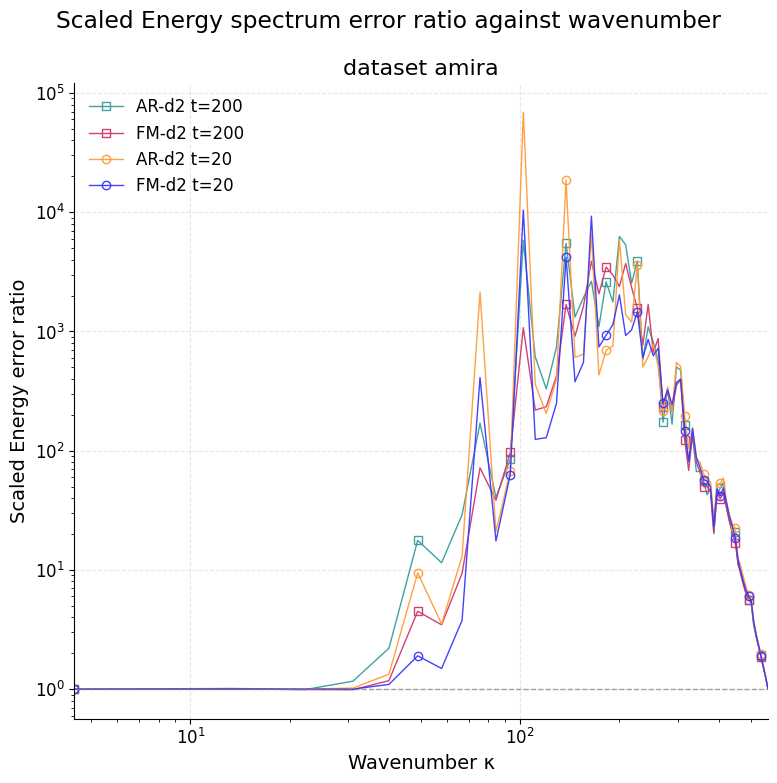

ar: [2.26004270e+00 1.02828250e+03 1.88028107e+03 5.23551583e+03
 7.26553725e+03 8.06447204e+05 1.30507202e+06 1.71905047e+06
 6.30881798e+06 3.18298415e+06]
q50: [1.15260125e+00 1.56102516e+02 4.55751725e+02 1.37027502e+03
 6.34279432e+03 1.56171882e+05 3.65242602e+05 1.02397267e+06
 3.54608600e+06 1.17756705e+07]
(64,) (64,) (64,)
ar: [9.96195879e-01 1.11560116e+00 5.03039028e+00 8.26036534e+00
 1.50331689e+01 2.21398312e+02 6.86445835e+02 2.14613892e+03
 9.52322310e+03 1.61230603e+04]
q50: [1.00066786e+00 1.00154960e+00 1.49702759e+00 1.99179726e+00
 4.04642568e+00 3.74741993e+01 1.05990846e+02 3.04866758e+02
 1.55780278e+03 4.37828013e+03]
(64,) (64,) (64,)


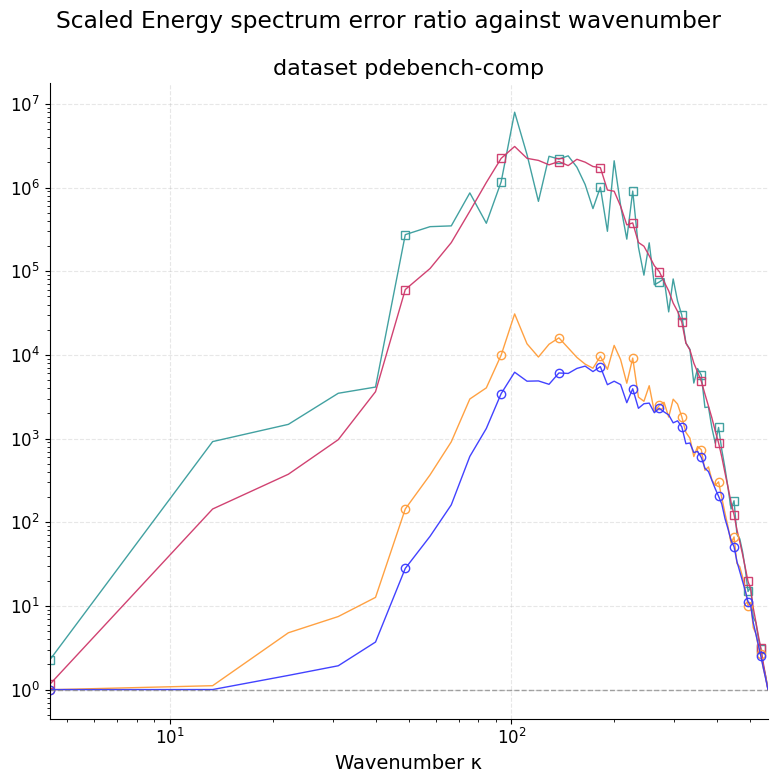

ar: [0.99843357 0.88330453 0.6304996  0.57699671 0.53737828 0.45143058
 0.44657332 0.564216   0.63010116 0.88382056]
q50: [0.99043334 0.90278268 0.69417122 0.67337668 0.72302509 0.76646637
 0.80924158 0.90531531 0.93320466 1.05905763]
(64,) (64,) (64,)
ar: [0.99926452 0.99887374 0.99816998 1.00349032 1.01566824 1.07938578
 1.25912519 2.00708647 3.42596607 7.20444811]
q50: [0.99894445 0.99866011 0.99213016 0.97611607 0.9798559  0.98215756
 1.02982093 1.18810378 1.58607814 2.59796182]
(64,) (64,) (64,)


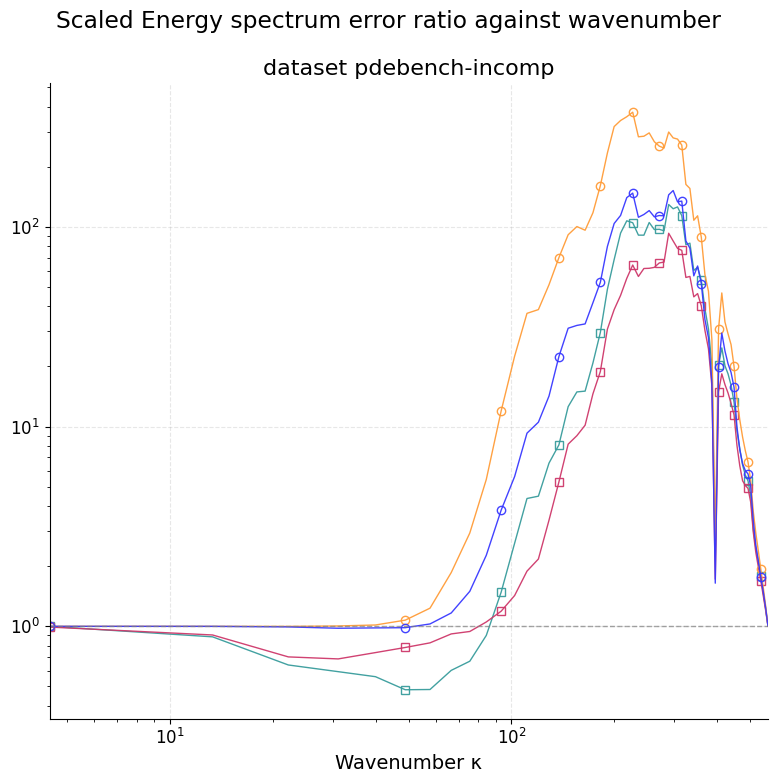

ar: [0.99542402 0.99691574 0.99406801 0.98703929 0.97500971 0.95995974
 0.94392648 0.91511873 0.9185115  0.90214292]
q50: [1.00283911 0.99805296 0.99203258 0.9815465  0.97186823 0.95756814
 0.94886326 0.93234475 0.92261546 0.89021746]
(64,) (64,) (64,)
ar: [1.00032727 1.00022073 0.99995098 1.00070757 0.9995778  0.99733347
 0.99740308 0.99045474 0.99849441 0.98189868]
q50: [1.00020229 1.00016989 0.99993376 0.99978559 0.99943579 0.99862412
 0.99873305 0.99456123 0.98724116 0.96710047]
(64,) (64,) (64,)


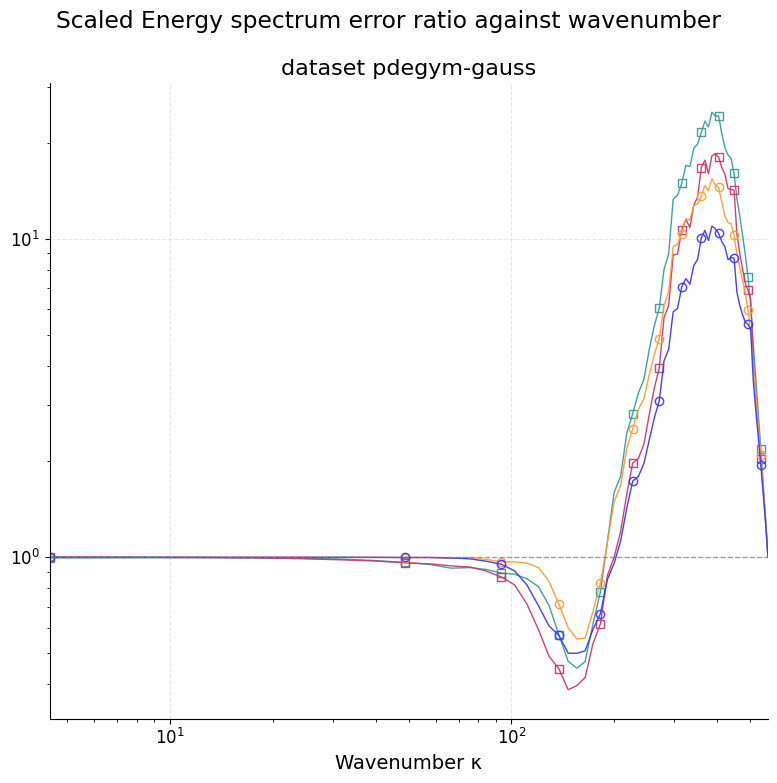

ar: [0.98639683 0.99217918 0.99456863 0.98548023 0.98148458 0.98102278
 0.97263602 0.95534951 0.99293097 0.97722923]
q50: [1.00813758 1.00316709 0.98819034 0.97948889 0.97284484 0.96693578
 0.96079694 0.94811473 0.96809316 0.94191988]
(64,) (64,) (64,)
ar: [1.00026463 0.99976863 1.001086   1.00134127 1.00073987 1.00029526
 1.00010099 0.99295486 1.00905396 0.98888508]
q50: [0.99938263 0.99913821 0.99882832 0.99845063 0.99759863 0.99652438
 0.99660088 0.99420404 0.99615192 0.98338332]
(64,) (64,) (64,)


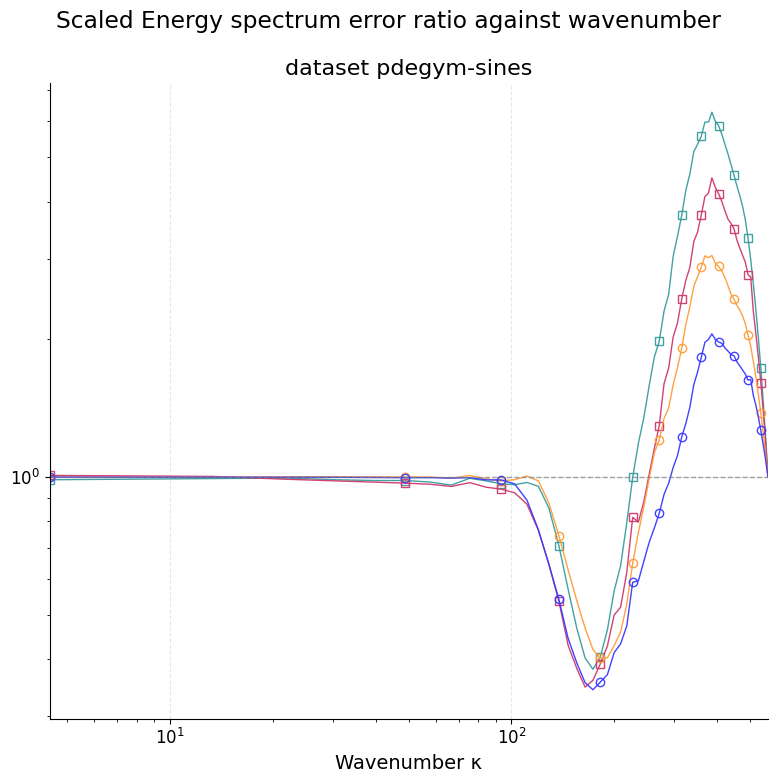

ar: [0.99921899 1.00375557 1.00568578 1.00396434 0.99664668 0.98426137
 0.96074118 0.93581133 0.92729837 0.90243298]
q50: [1.00145111 1.00159112 0.99310428 0.98419489 0.97836413 0.970033
 0.95666551 0.93651213 0.90768629 0.86599129]
(64,) (64,) (64,)
ar: [1.00086224 1.00096035 1.00138369 1.00198377 1.00276329 1.00326006
 1.00370191 0.99526601 1.01037513 0.9983886 ]
q50: [1.00030798 0.99984632 1.00019537 0.99930619 0.99841311 0.99754379
 0.99727206 0.99417096 0.99498941 0.9864814 ]
(64,) (64,) (64,)


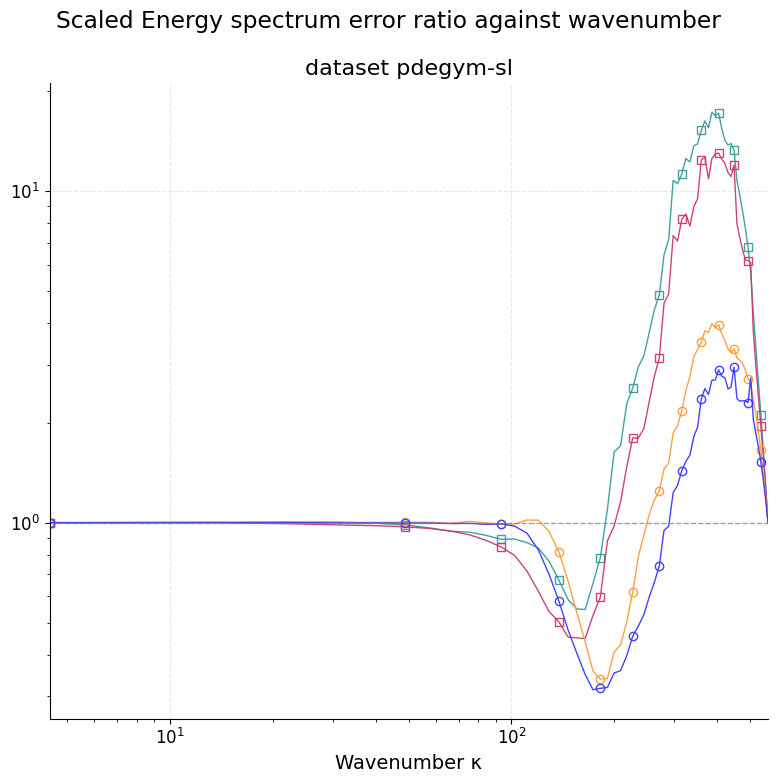

ar: [1.02457695 1.03789434 1.04222925 1.00265812 1.0623927  1.05513415
 1.03267659 1.00762509 0.93266609 0.85833424]
q50: [1.00443871 1.00559927 0.97816734 0.99803044 0.96773599 0.96903921
 0.96556274 0.95135168 0.9048195  0.82798697]
(64,) (64,) (64,)
ar: [1.00311402 1.001003   1.00063306 1.0010232  1.00357355 1.00767304
 1.01568753 1.00619739 1.02701641 1.03027301]
q50: [0.99979873 0.99969988 0.99898323 0.99874797 0.99849741 0.99840692
 0.99795646 0.9926967  0.9899494  0.97748603]
(64,) (64,) (64,)


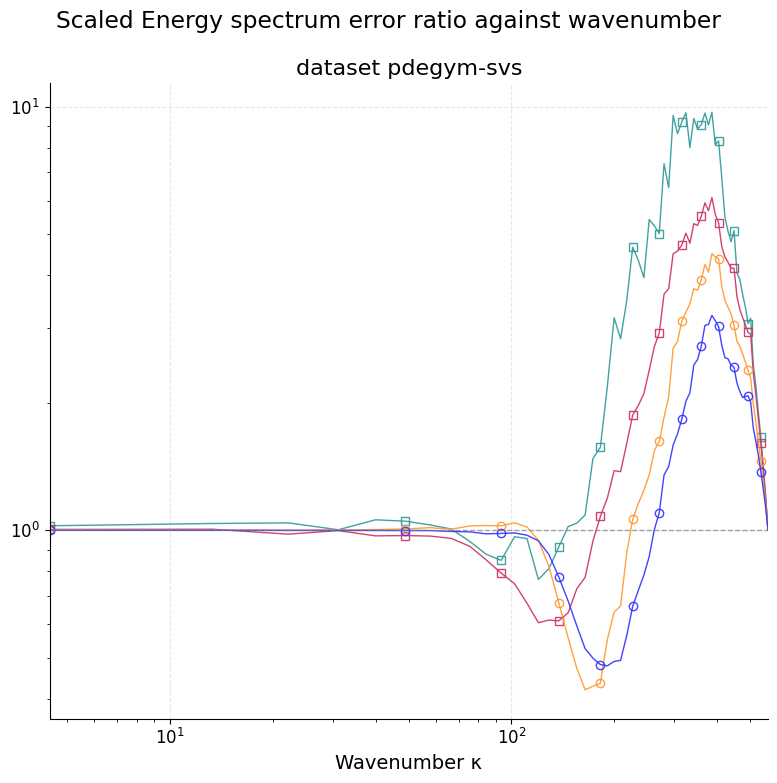

ar: [0.9941555  0.99644377 1.00236861 1.00499928 1.00765233 1.01061773
 0.99267937 0.95092656 1.00435222 0.99716103]
q50: [0.99943011 1.00156338 0.99900814 0.99585884 0.99448722 0.9960952
 0.99589982 0.98680372 1.03582423 1.0364661 ]
(64,) (64,) (64,)
ar: [1.00014921 1.00036381 1.00106218 1.00181061 1.00319429 1.00541878
 1.00881218 0.99894592 1.00569205 0.96675874]
q50: [0.9999035  0.99992118 0.99977599 0.99961405 0.99974658 1.00035436
 1.00115544 0.99919507 1.00556123 0.98180412]
(64,) (64,) (64,)


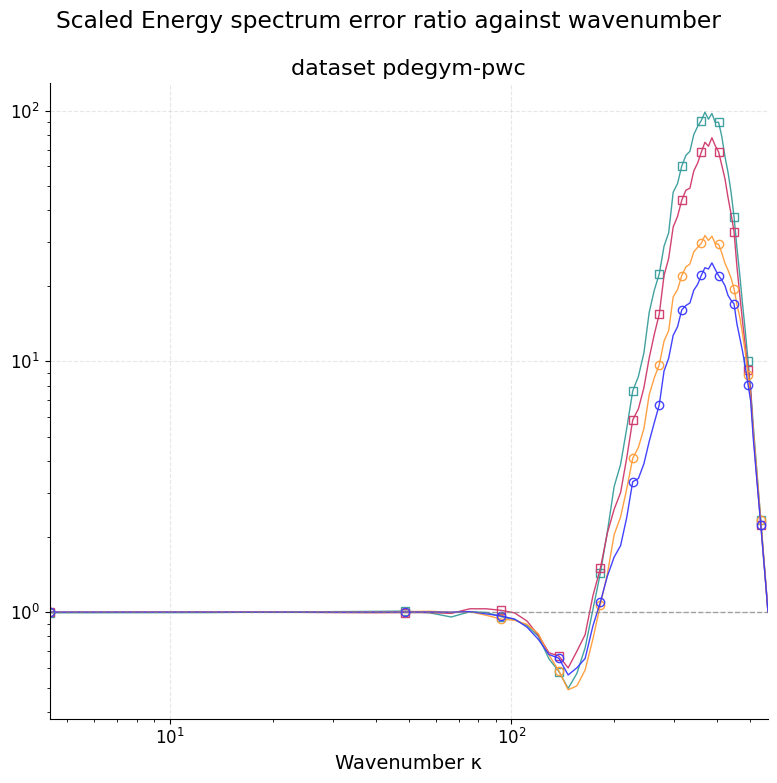

ar: [1.00210655 0.99695999 1.00395028 1.0111068  1.01900456 1.01830276
 0.98815286 0.93793899 1.04150529 1.04432218]
q50: [1.00239386 1.00391364 1.00158153 0.99701073 0.9959989  0.99886669
 1.000083   0.99706477 1.08520233 1.08383167]
(64,) (64,) (64,)
ar: [1.00067919 1.00102967 1.00232492 1.00252294 1.00385439 1.00585326
 1.00906516 0.99863769 1.00753128 0.96933894]
q50: [0.99989332 0.99989046 0.9998136  0.99970474 1.000005   1.00061659
 1.00145411 1.00118018 1.01302972 0.99776627]
(64,) (64,) (64,)


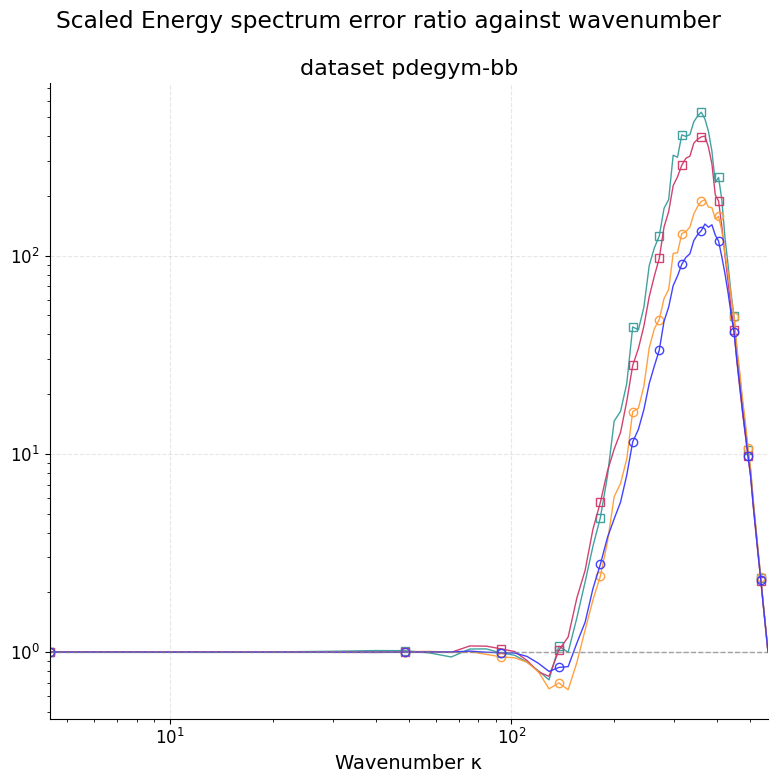

ar: [  1.00103459   0.9963197    1.01717807   3.66977578   5.00654777
  32.43901725  83.98646464 523.79719792 548.64746484 596.42129115]
q50: [  1.00025716   0.99923614   0.99612745   1.09283357   1.88691825
   6.81810008  17.20036883 105.15591291 185.25481502 481.00585651]
(64,) (64,) (64,)
ar: [1.00173649e+00 1.00386437e+00 1.01500236e+00 1.71907091e+00
 5.84568501e+01 2.17121100e+01 1.18892406e+02 1.55931357e+03
 2.01909368e+04 1.70106178e+03]
q50: [9.99683292e-01 1.00513868e+00 1.00167757e+00 1.13023136e+00
 2.42523910e+01 6.57967746e+00 2.52742863e+01 2.67990602e+02
 4.09907467e+03 1.24961994e+03]
(64,) (64,) (64,)


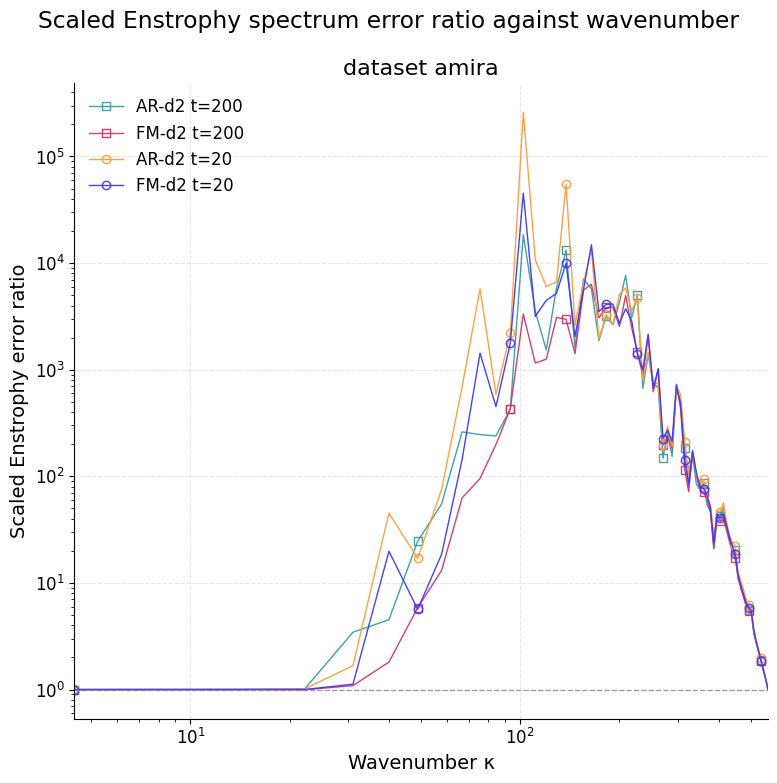

ar: [1.75898348e+01 1.36264565e+03 2.48408804e+03 7.30954521e+03
 1.34731269e+04 6.74564530e+05 2.92519687e+06 4.94599497e+06
 1.54414580e+07 9.31938334e+06]
q50: [1.92417743e+00 1.11369725e+02 2.92815310e+02 9.94466511e+02
 7.87429832e+03 2.68716149e+05 5.51020434e+05 2.68779958e+06
 1.06646056e+07 2.69279966e+07]
(64,) (64,) (64,)
ar: [1.00077734e+00 1.23319415e+00 4.01848005e+00 5.55884257e+00
 1.59082347e+01 1.90633510e+02 6.74459616e+02 3.57928700e+03
 9.93718798e+03 1.70917384e+04]
q50: [9.95667159e-01 1.01647250e+00 1.23609307e+00 1.54762354e+00
 3.32415932e+00 3.59429498e+01 9.28785978e+01 3.89951818e+02
 1.63644928e+03 3.81112506e+03]
(64,) (64,) (64,)


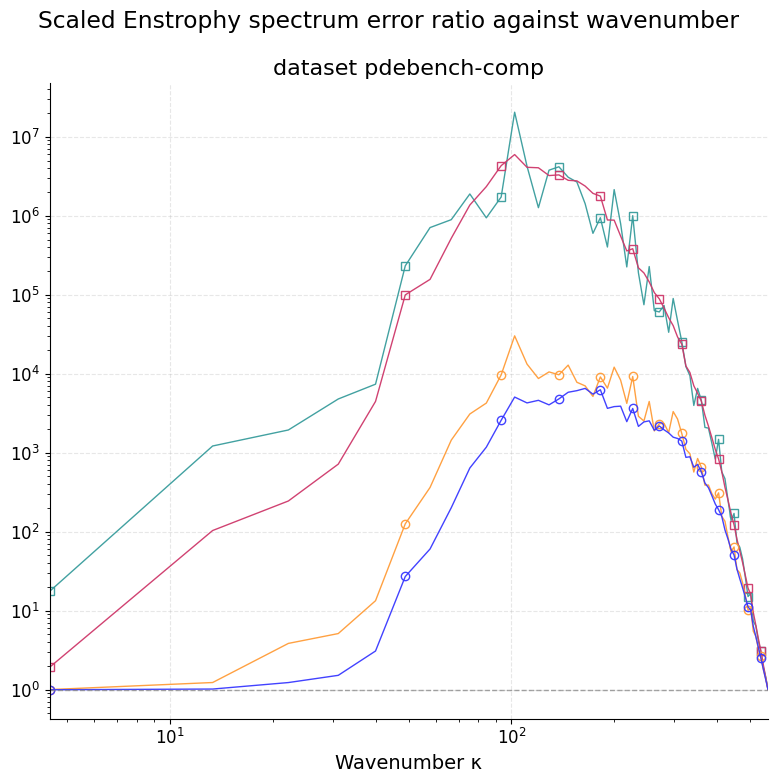

ar: [1.00061978 0.87780134 0.62017862 0.57807321 0.53160648 0.4461483
 0.44351456 0.55485922 0.61007846 0.82597624]
q50: [0.97831633 0.89210387 0.68344408 0.67712385 0.72190492 0.76288398
 0.80792951 0.90211307 0.92282193 1.03471991]
(64,) (64,) (64,)
ar: [0.99918376 0.99896339 0.99805834 1.00204894 1.00840207 1.05292356
 1.17000197 1.76075597 2.91099853 5.74118465]
q50: [0.99887123 0.99853146 0.99086734 0.97590455 0.97926252 0.97791289
 1.01898665 1.15927846 1.50026307 2.37379447]
(64,) (64,) (64,)


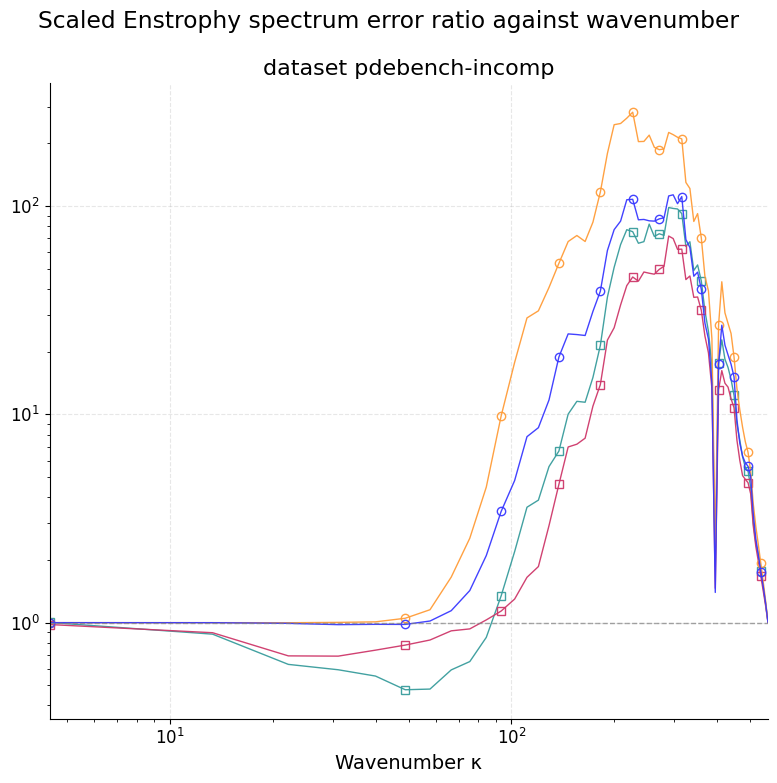

ar: [0.99513414 0.99645428 0.99337639 0.98658048 0.97449345 0.95915637
 0.942946   0.91400443 0.91777928 0.89994863]
q50: [1.00243002 0.99782811 0.99122522 0.98115722 0.97140254 0.95707512
 0.94849947 0.93158747 0.92187908 0.88891452]
(64,) (64,) (64,)
ar: [1.00028409 1.00018361 1.00000429 1.00066634 0.99941992 0.99708627
 0.99698227 0.9897517  0.99755017 0.97953665]
q50: [1.00019935 1.0001597  0.99991335 0.99976326 0.99939146 0.99854076
 0.99860925 0.99416813 0.98664727 0.96609188]
(64,) (64,) (64,)


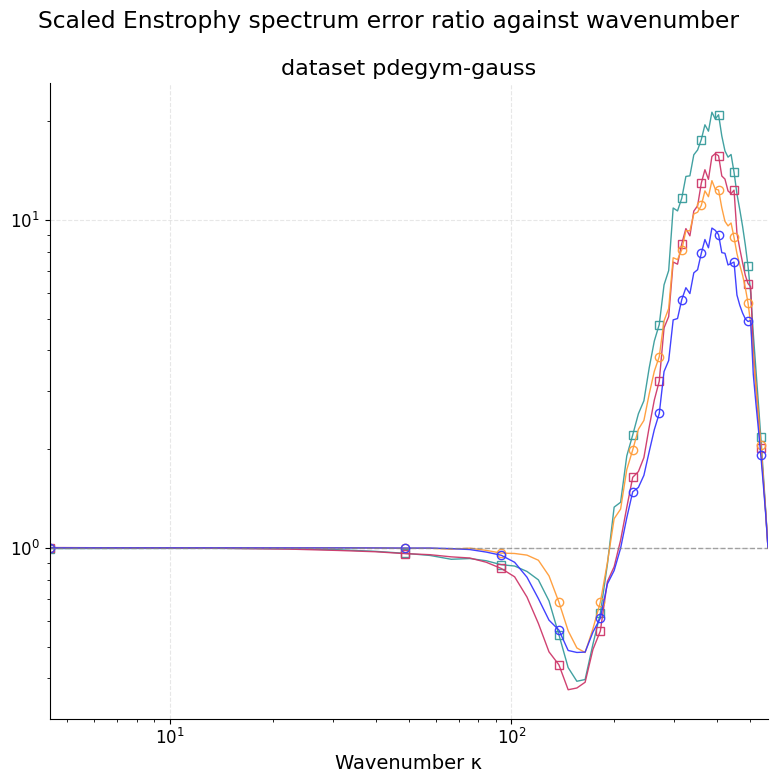

ar: [0.98855722 0.99258483 0.99394603 0.98516236 0.9813943  0.98060181
 0.97181597 0.95527554 0.99285757 0.97637162]
q50: [1.00885658 1.00340528 0.98721672 0.97910976 0.97247963 0.96676939
 0.96016633 0.94779118 0.96765511 0.9414734 ]
(64,) (64,) (64,)
ar: [1.00001418 0.99972951 1.0011158  1.00129724 1.0006969  1.00026374
 0.99989981 0.99286873 1.00874923 0.98803941]
q50: [0.99932662 0.99911742 0.99880446 0.99842441 0.99755485 0.99649462
 0.99656216 0.99410932 0.99592308 0.9832348 ]
(64,) (64,) (64,)


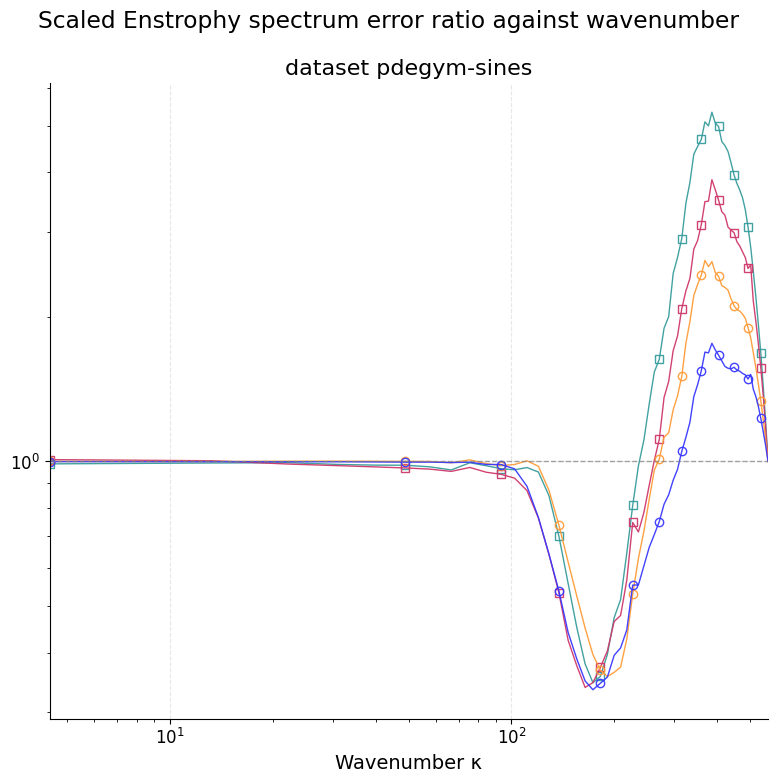

ar: [0.99894144 1.00387945 1.0057704  1.00378696 0.99615824 0.98335947
 0.9595452  0.93432331 0.92560705 0.89913362]
q50: [1.00184121 1.00118596 0.99258909 0.98396976 0.97798738 0.9695656
 0.95597907 0.93548654 0.90633686 0.8640744 ]
(64,) (64,) (64,)
ar: [1.00086555 1.00087822 1.00136319 1.00199512 1.0027761  1.00317519
 1.0033936  0.99489443 1.01015284 0.99733189]
q50: [1.00030846 0.99984713 1.00014193 0.9992903  0.99832943 0.99747939
 0.99721758 0.99394289 0.99482349 0.98627902]
(64,) (64,) (64,)


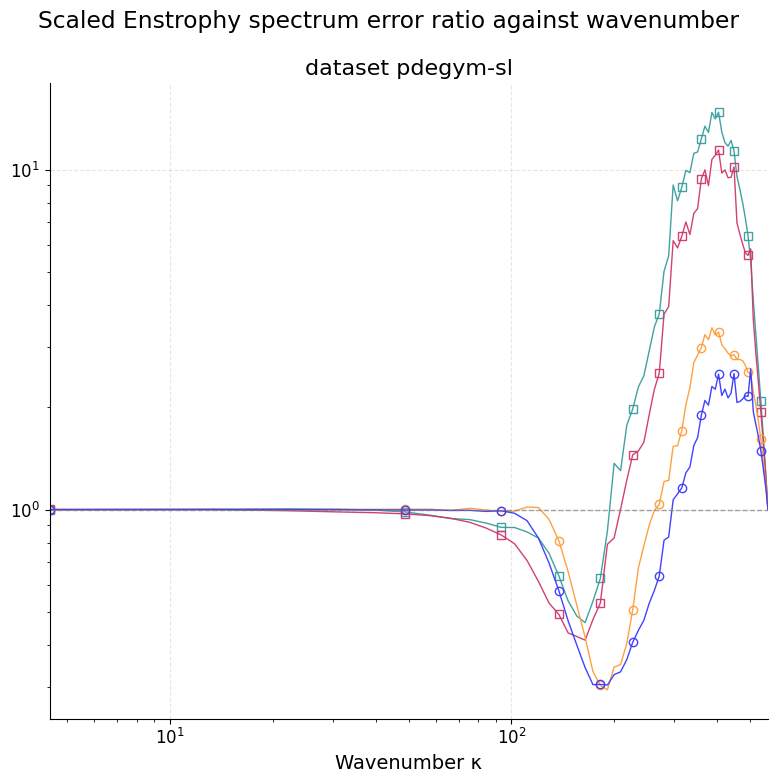

ar: [1.02258239 1.03199876 1.04183416 1.00756673 1.06129932 1.0529491
 1.03079867 1.00239475 0.92622309 0.84581208]
q50: [1.00531585 1.00496206 0.98008786 0.99740051 0.96770626 0.97009828
 0.96512522 0.95012995 0.90239249 0.82471538]
(64,) (64,) (64,)
ar: [1.00288798 1.00111312 1.00051756 1.00085746 1.00363833 1.0079714
 1.01595766 1.00636512 1.02705007 1.02927553]
q50: [0.99981809 0.99971925 0.9989462  0.99873498 0.99845517 0.99842958
 0.99792116 0.99230502 0.989644   0.97710597]
(64,) (64,) (64,)


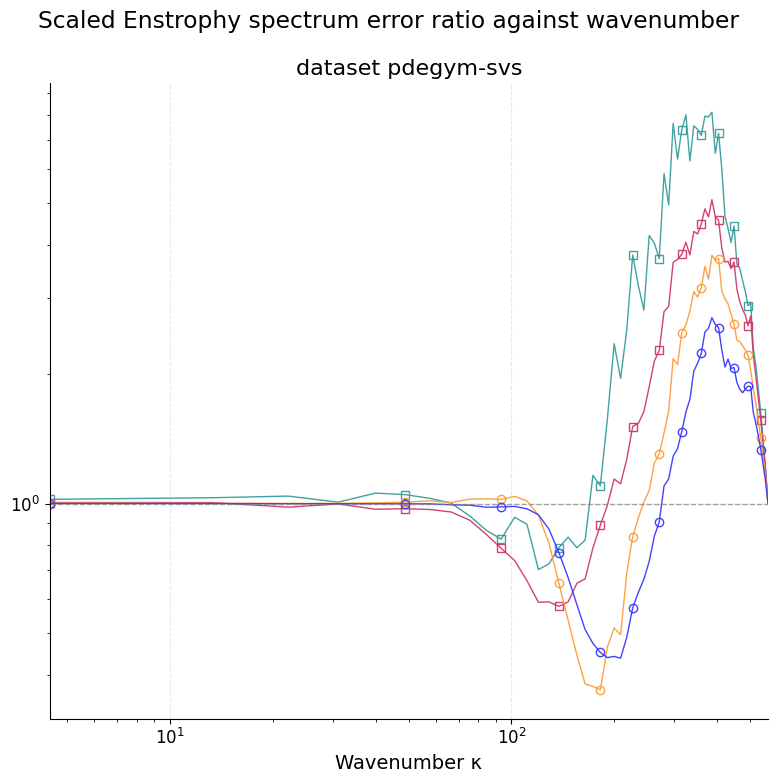

ar: [0.99363307 0.99641493 1.00260263 1.0049919  1.00775208 1.01035954
 0.99160543 0.95064143 1.00508546 0.99558351]
q50: [0.99942162 1.00150737 0.99872144 0.99576445 0.99445208 0.9961894
 0.99567333 0.98703052 1.0364929  1.03572809]
(64,) (64,) (64,)
ar: [1.00010147 1.00044174 1.00109533 1.00185545 1.00322932 1.00545527
 1.00864639 0.99851829 1.00495485 0.96488887]
q50: [0.99990686 0.99991792 0.99975818 0.9996096  0.99975094 1.00036777
 1.00110881 0.99913425 1.00525372 0.98090393]
(64,) (64,) (64,)


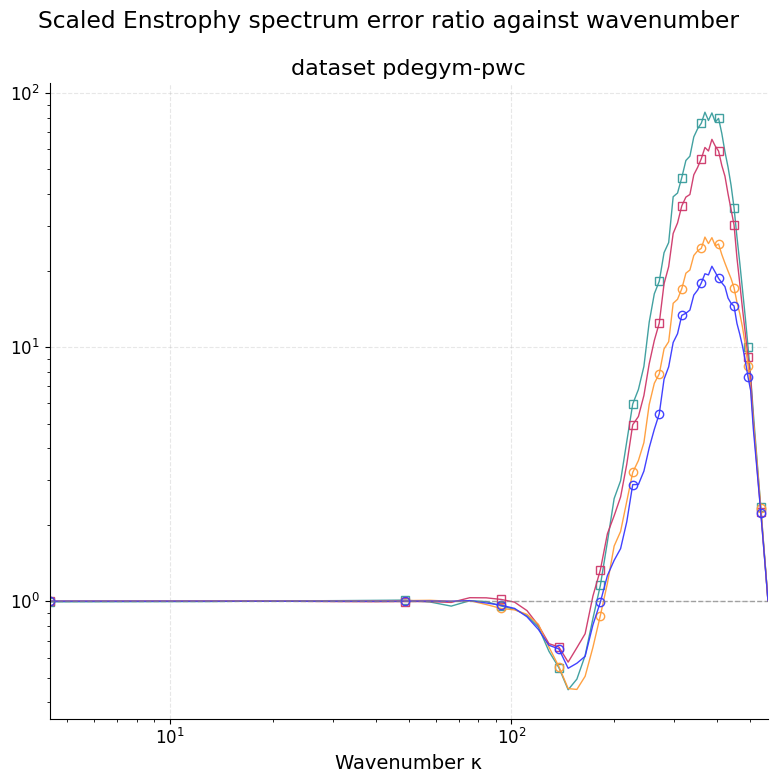

ar: [1.00180393 0.99683506 1.00452007 1.01138627 1.0191777  1.01769305
 0.98662868 0.93811786 1.04316787 1.04235975]
q50: [1.00244457 1.00394821 1.00123043 0.99687039 0.99601955 0.99897771
 0.99988149 0.99779083 1.08647474 1.08247902]
(64,) (64,) (64,)
ar: [1.00060484 1.00106996 1.00233771 1.00255271 1.00387985 1.00583896
 1.00893353 0.99828497 1.00710779 0.96787512]
q50: [0.99989175 0.99988737 0.99979108 0.99969909 1.0000113  1.00062639
 1.00143324 1.0012289  1.01293995 0.99716272]
(64,) (64,) (64,)


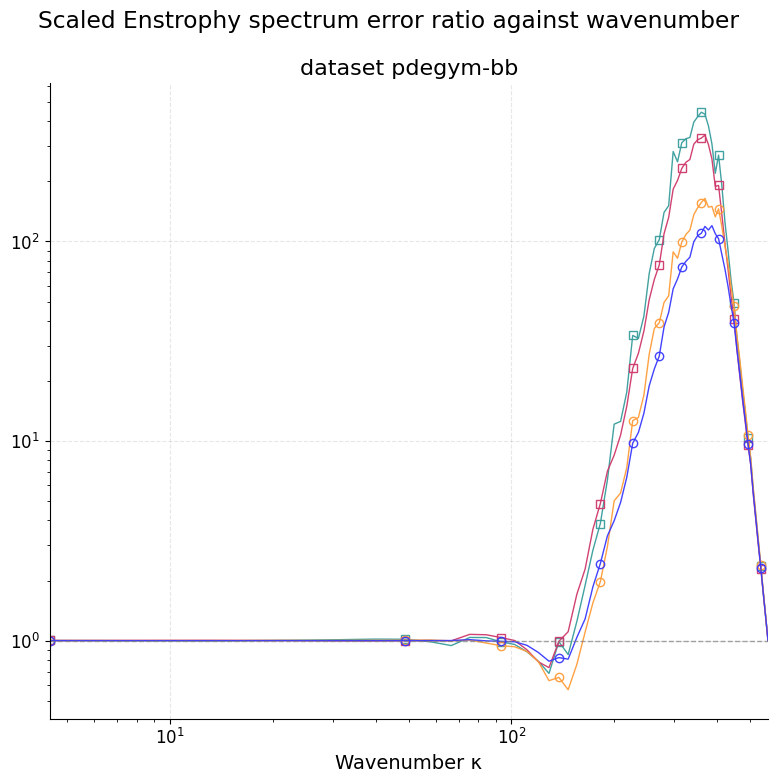

In [41]:
base_path_ar = "../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/spectra_error/"
base_path_ar2 = "../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/spectra_error/"
base_path_fm = "../../FluidGPT_validation/final_data/FM/fm-d2-9/spectra_error/"
base_path_fm2 = "../../FluidGPT_validation/final_data/FM/fm-d3-6/spectra_error/"
spectrum_actual = ["Energy", "Enstrophy"]
linestyles = ['-', '--', ':']
markers = ['o', 's', '^']
datasets_focus = datasets_all #["amira", "pdegym-sines", "pdegym-bb"]


for spectrum_type, spectrum_name in zip(["E", "Z"], spectrum_actual):

    #ax = ax.flatten()
    for dataset_idx, dataset_name in enumerate(datasets_focus):
        fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 8), sharex=True)
        
        if dataset_name == "amira" or dataset_name == "pdebench-incomp":
            timestep_list = ["=5", "=20", "final"]
            if dataset_name == "amira":
                #timestep_actual = ["5", "20", "200"]
                timestep_actual = ["20", "200"]
            if dataset_name == "pdebench-incomp":
                timestep_actual = ["20", "100"]
        else:
            timestep_list = ["=5", "=20"]
            timestep_actual = ["5", "20"]

        k_filename = f"{base_path_ar}k_steps_{dataset_name}.json"

        with open(k_filename, "r") as f:
            k_steps = json.load(f)

        for c, (t, timestep) in reversed(list(enumerate(zip(timestep_actual, timestep_list)))):
            
            filename_ar = f"{base_path_ar}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            filename_fm = f"{base_path_fm}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            
            with open(filename_ar, "r") as f:
                data_ar = np.array(json.load(f))
            with open(filename_fm, "r") as f:
                data_fm = np.array(json.load(f))
            avg_fm = np.mean(data_fm, axis=(1,2))
            avg_ar = np.mean(data_ar, axis=1)

            q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=(2))
            q0 = np.mean(q0, axis=1)
            q25 = np.mean(q25, axis=1)
            q50 = np.mean(q50, axis=1)
            q75 = np.mean(q75, axis=1)
            q100 = np.mean(q100, axis=1)

            #avg_ar = avg_ar / k_steps
            #q50 = q50 / k_steps # scale by wavenumber
            k_steps = np.array(k_steps)
            kmin = np.min(k_steps)
            kmax = np.max(k_steps)
            p = 1
            alpha = 1 - ((k_steps - kmin)/(kmax - kmin))**(1/p)
            print("ar:", end=" ")
            print(avg_ar[:10])
            print("q50:", end=" ")
            print(q50[:10])
            avg_ar = avg_ar**alpha
            q50 = q50**alpha

            print(avg_ar.shape, q50.shape, k_steps.shape)
            ################################################################################# 
            ax.plot(k_steps, avg_ar, label=f'AR-d2 t={t}', linewidth=1, color=colors[c], alpha=0.95, marker=markers[c], markevery=5)
            #ax[dataset_idx].plot(k_steps, avg_fm, label=f'FM-d2 t={t}', linewidth=1, color=colors[c+2], alpha=0.95, marker=markers[c], markevery=5)
            ax.plot(k_steps, q50, label=f'FM-d2 t={t}', linewidth=1, color=colors[c+2], alpha=0.95, marker=markers[c], markevery=5)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel("Wavenumber κ")
        if dataset_idx == 0:
            ax.set_ylabel(f"Scaled {spectrum_name} error ratio")
        #ax[dataset_idx].set_title(f"{spectrum_name} spectrum error ratio against wavenumber for dataset {dataset_name}")
        ax.set_title(f"dataset {dataset_name}")
        #ymin, _ = ax[dataset_idx].get_ylim()
        #ax[dataset_idx].set_ylim(0.1, 1e8) 
        if dataset_idx == 0:
            ax.legend(ncol=1, loc='upper left')
        ax.minorticks_on()
        ax.hlines(y=1, xmin=k_steps[0], xmax=k_steps[-1], color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlim(k_steps[0], k_steps[-1])
        fig.suptitle(f"Scaled {spectrum_name} spectrum error ratio against wavenumber")
        plt.tight_layout()
        #plt.savefig(f"../../report/figs/results/spectra/spectrum_{spectrum_type}.png", dpi=300)
        plt.show()

In [43]:
raise NotImplementedError

NotImplementedError: 

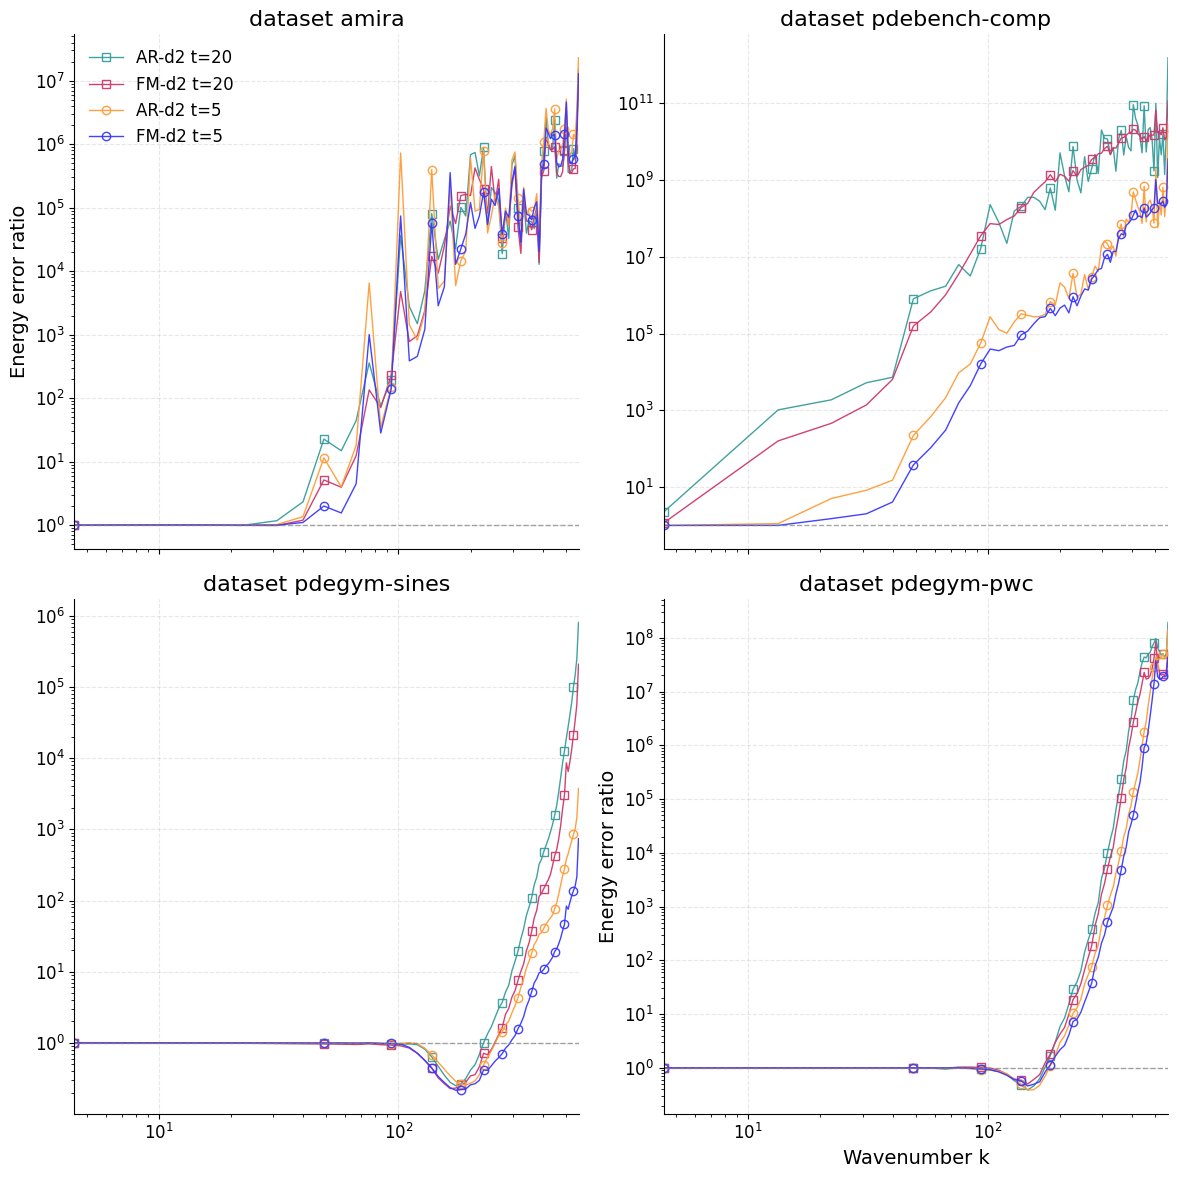

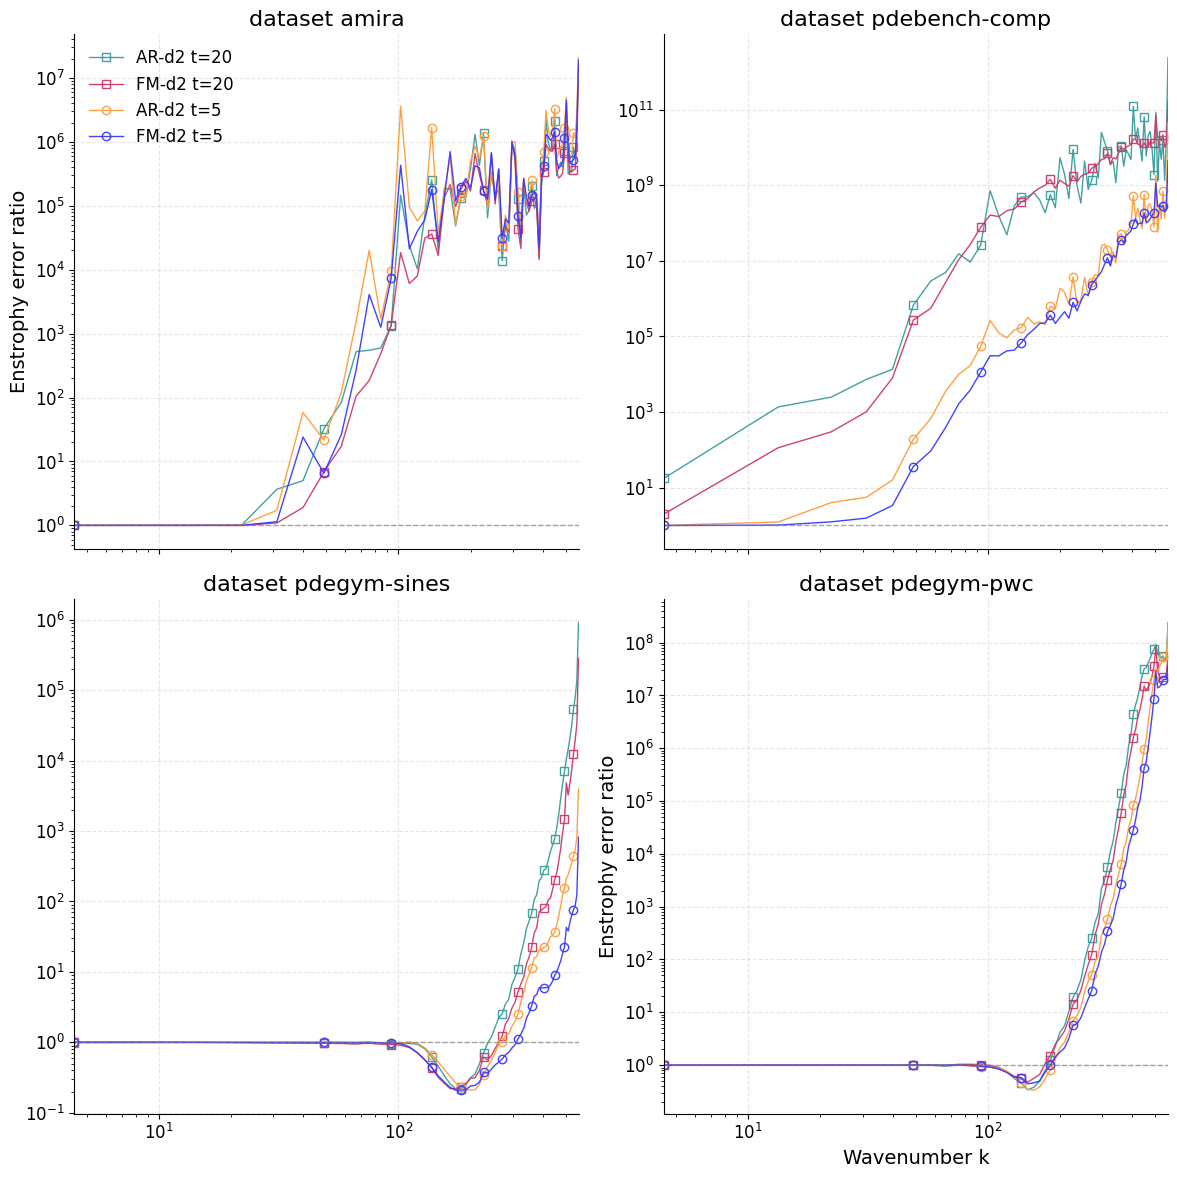

In [17]:
base_path_ar = "../../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/spectra_error/"
base_path_ar2 = "../../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/spectra_error/"
base_path_fm = "../../../FluidGPT_validation/final_data/FM/fm-d2-9/spectra_error/"
base_path_fm2 = "../../../FluidGPT_validation/final_data/FM/fm-d3-6/spectra_error/"
spectrum_actual = ["Energy", "Enstrophy"]
linestyles = ['-', '--', ':']
markers = ['o', 's', '^']
datasets_focus = ["amira", "pdebench-comp", "pdegym-sines", "pdegym-pwc"]


######################## ADJUSTMENT ON COLORS AND PRESENTATION NEEDED
# show only two best models d2 for simplicity
# pdebench shouldnt actually be spectrualized because its compressible and we calculate with incompressibility condition
# focus on 4 datasets that show significant difference in rollout
# focus on energy spectrum only i suggest, put enstrophy spectr in appendix
# why do higher frequencies matter less -> refer to characteristic decay of vortices figure + dividing removes the magnitude
# first present a typical energy spectr for each datatype?
# sines is initialised in a very out-of-distribution way for the energy spectrum
# which error?


for spectrum_type, spectrum_name in zip(["E", "Z"], spectrum_actual):
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 12), sharex=True)#, sharey=True)
    ax = ax.flatten()
    for dataset_idx, dataset_name in enumerate(datasets_focus):
        """
        if dataset_name == "amira" or dataset_name == "pdebench-incomp":
            timestep_list = ["=5", "=20", "final"]
            if dataset_name == "amira":
                timestep_actual = ["5", "20", "200"]
            if dataset_name == "pdebench-incomp":
                timestep_actual = ["5", "20", "100"]
        else:
            timestep_list = ["=5", "=20"]
            timestep_actual = ["5", "20"]
        """
        timestep_list = ["=5", "=20"]
        timestep_actual = ["5", "20"]
        #timestep_list = ["=5", "=20"]
        #timestep_actual = ["5", "20"]
        k_filename = f"{base_path_ar}k_steps_{dataset_name}.json"
        #print(k_filename)
        with open(k_filename, "r") as f:
            k_steps = json.load(f)
        #print(f"k_steps length: {len(k_steps)}")
        # create figure
        
        for c, (t, timestep) in reversed(list(enumerate(zip(timestep_actual, timestep_list)))):
            
            filename_ar = f"{base_path_ar}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            filename_fm = f"{base_path_fm}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            
            with open(filename_ar, "r") as f:
                data_ar = np.array(json.load(f))
            with open(filename_fm, "r") as f:
                data_fm = np.array(json.load(f))
            avg_fm = np.mean(data_fm, axis=(1,2))
            avg_ar = np.mean(data_ar, axis=1)

            q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=(2))
            q0 = np.mean(q0, axis=1)
            q25 = np.mean(q25, axis=1)
            q50 = np.mean(q50, axis=1)
            q75 = np.mean(q75, axis=1)
            q100 = np.mean(q100, axis=1)
            
            ax[dataset_idx].plot(k_steps, avg_ar, label=f'AR-d2 t={t}', linewidth=1, color=colors[c], alpha=0.95, marker=markers[c], markevery=5)
            ax[dataset_idx].plot(k_steps, avg_fm, label=f'FM-d2 t={t}', linewidth=1, color=colors[c+2], alpha=0.95, marker=markers[c], markevery=5)

        ax[dataset_idx].set_xscale('log')
        ax[dataset_idx].set_yscale('log')
        if dataset_idx == 3 or dataset_idx == 4:
            ax[dataset_idx].set_xlabel("Wavenumber k")
        if dataset_idx == 0 or dataset_idx == 3:
            ax[dataset_idx].set_ylabel(f"{spectrum_name} error ratio")
        #ax[dataset_idx].set_title(f"{spectrum_name} spectrum error ratio against wavenumber for dataset {dataset_name}")
        ax[dataset_idx].set_title(f"dataset {dataset_name}")
        #ymin, _ = ax[dataset_idx].get_ylim()
        #ax[dataset_idx].set_ylim(0.1, 10e10) 
        if dataset_idx == 0:
            ax[dataset_idx].legend(ncol=1, loc='upper left')
        ax[dataset_idx].minorticks_on()
        ax[dataset_idx].hlines(y=1, xmin=k_steps[0], xmax=k_steps[-1], color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax[dataset_idx].set_xlim(k_steps[0], k_steps[-1])
    plt.tight_layout()
    plt.savefig(f"../../report/figs/results/spectra/spectrum_{spectrum_type}.png", dpi=300)
    plt.show()

STOP HERE

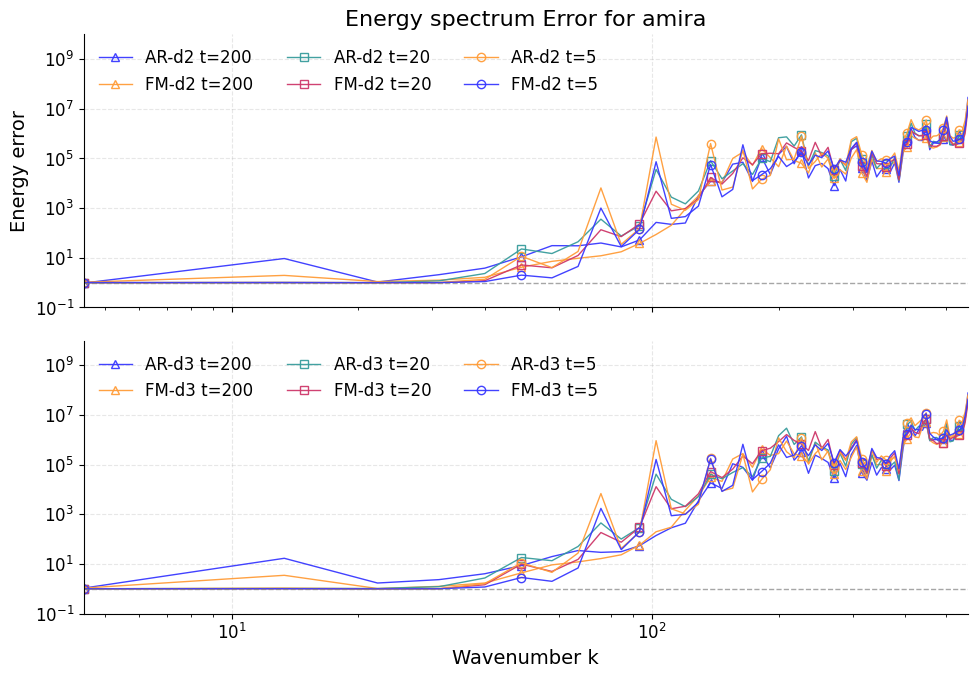

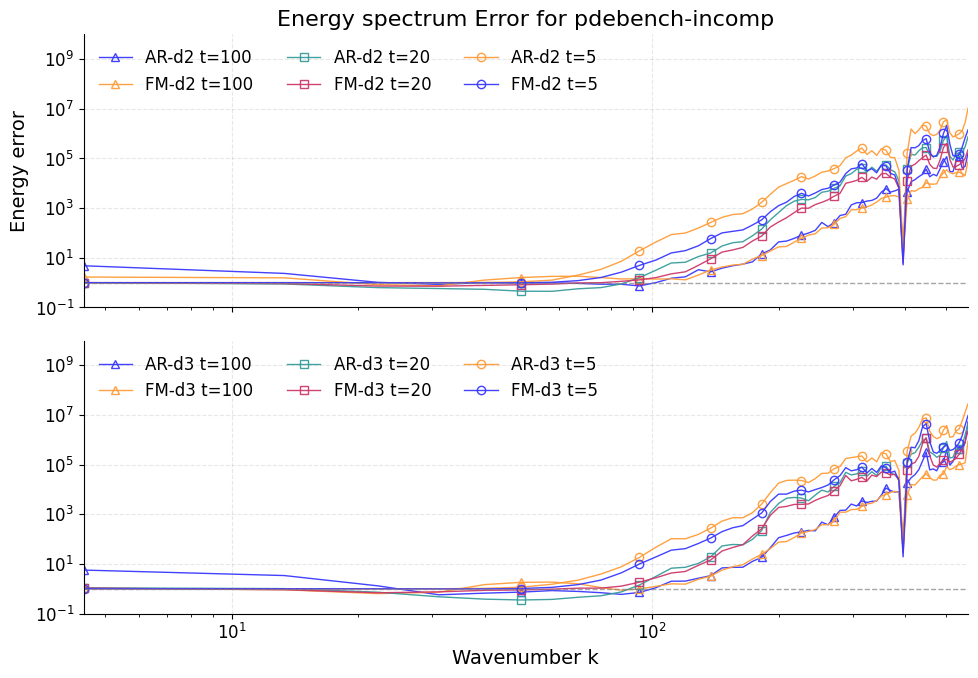

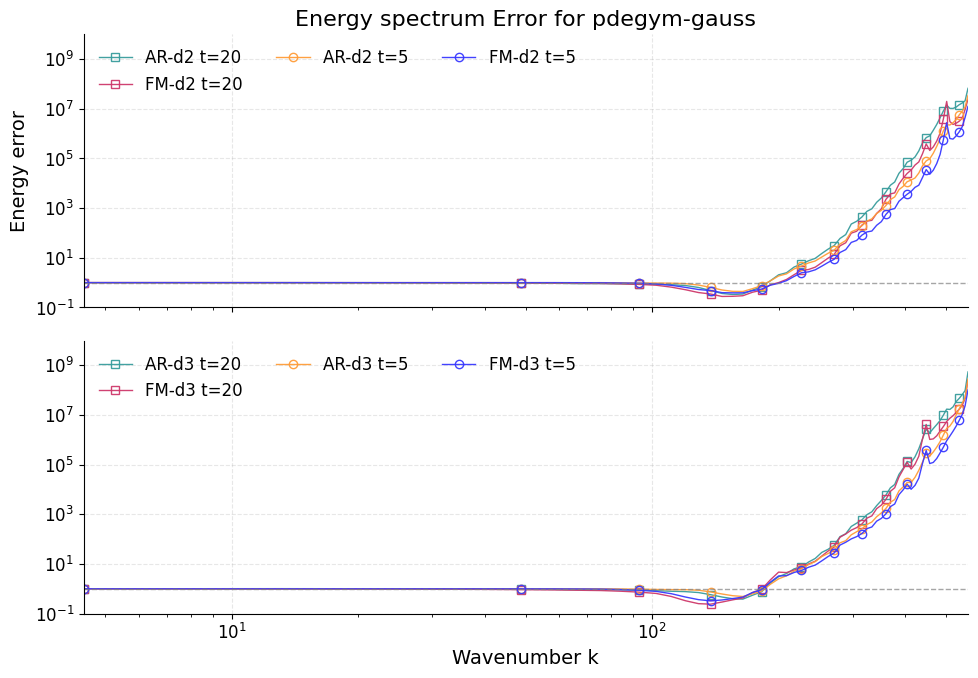

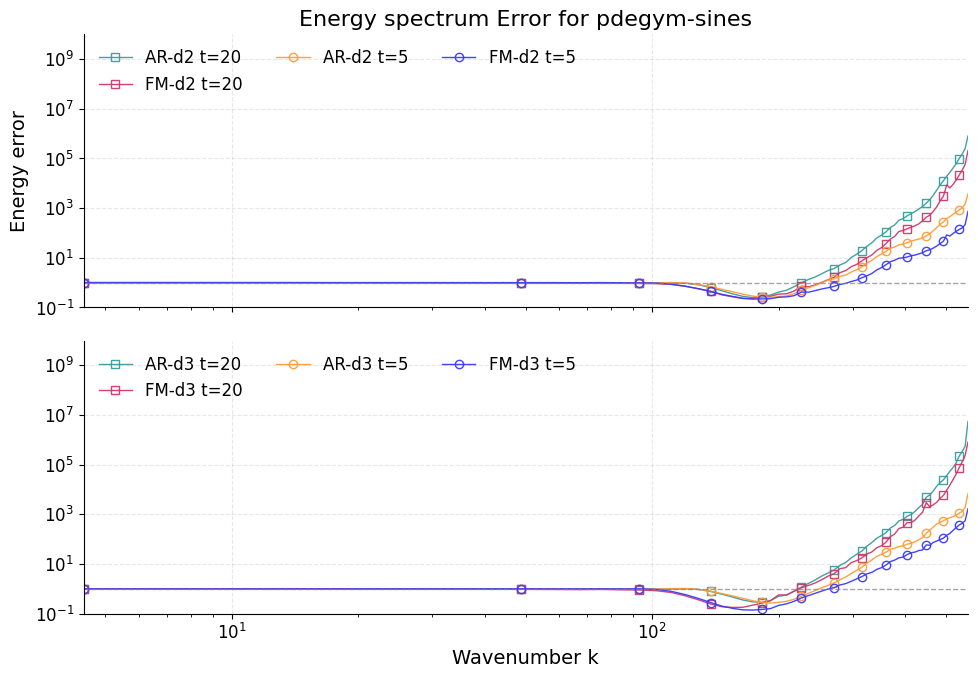

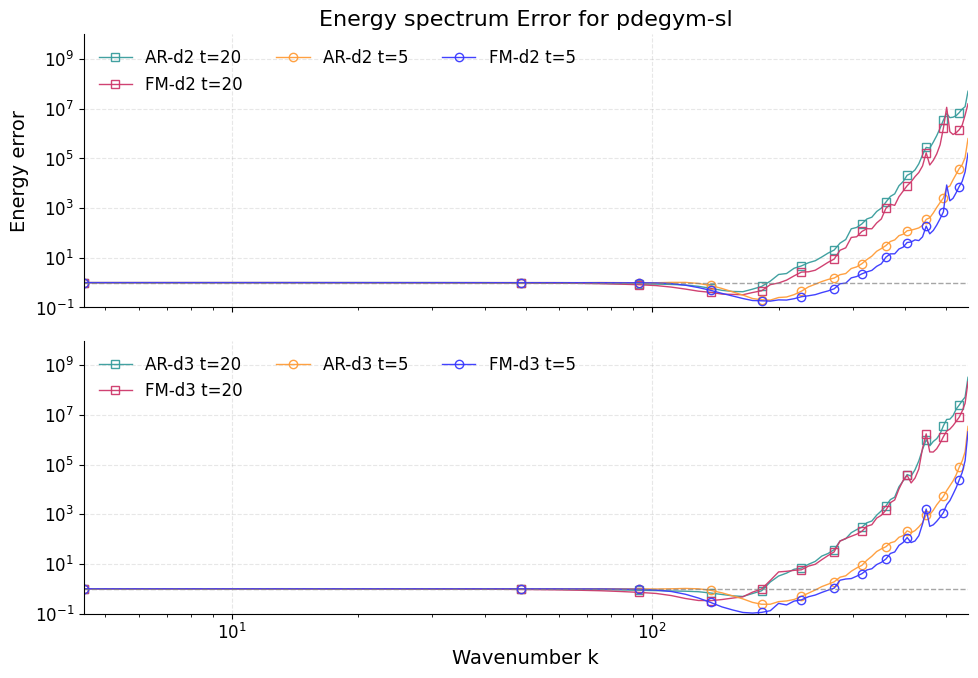

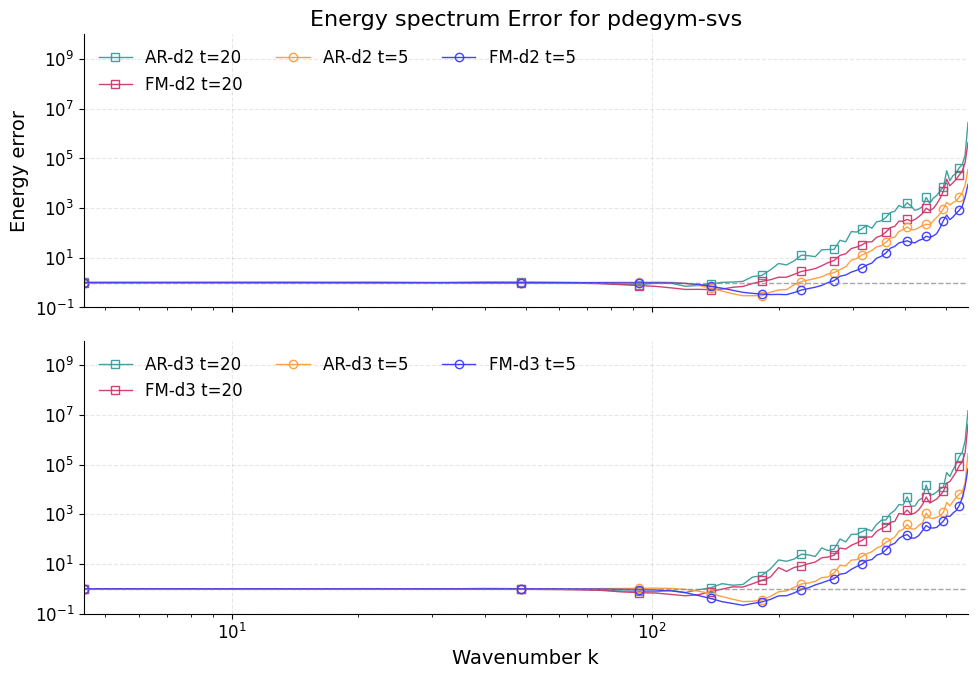

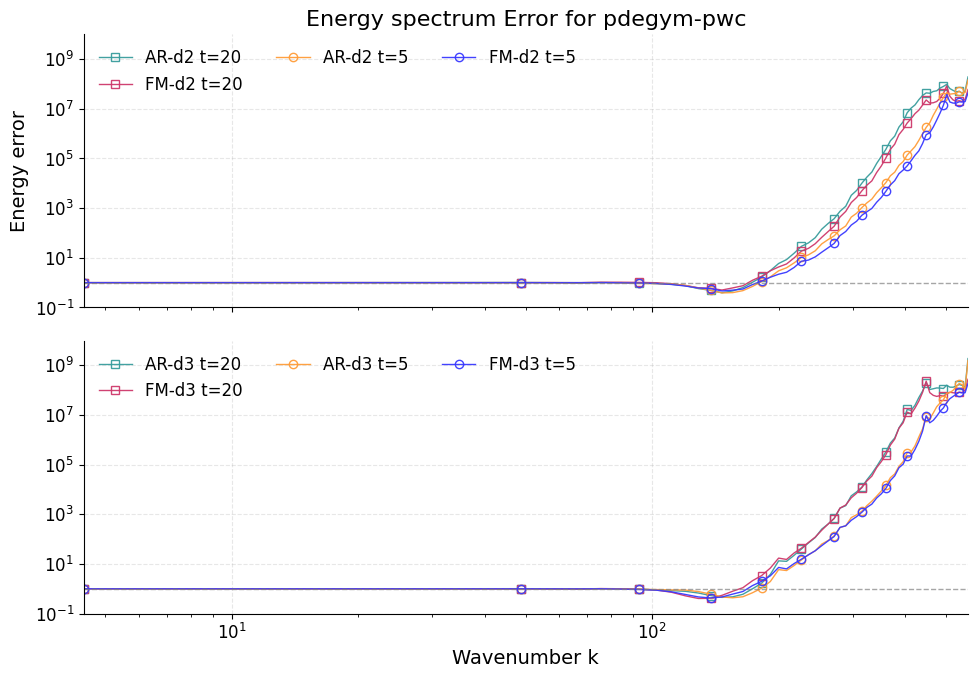

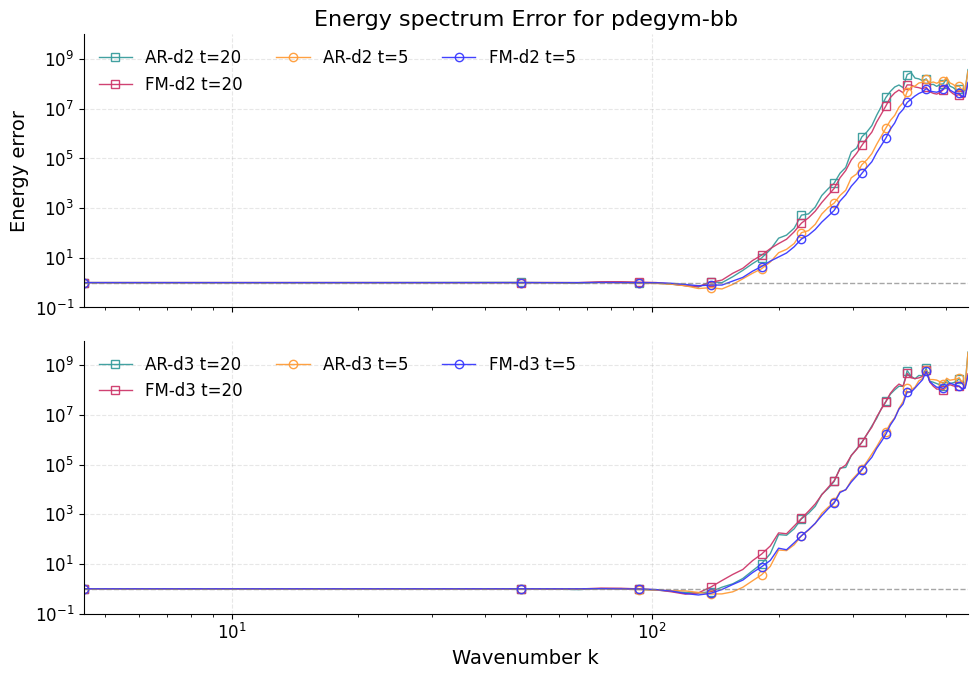

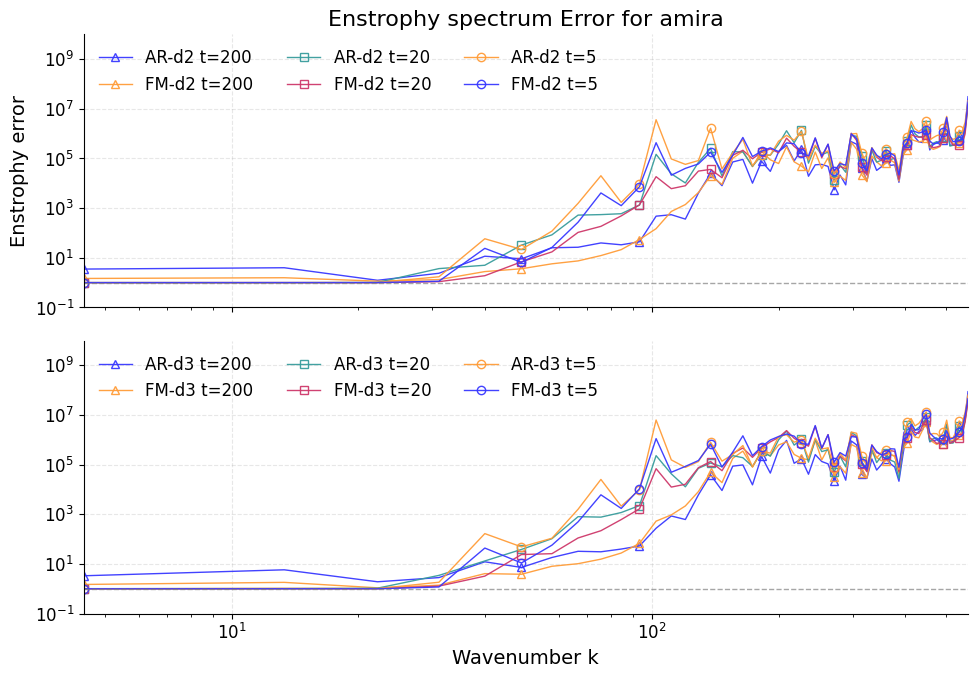

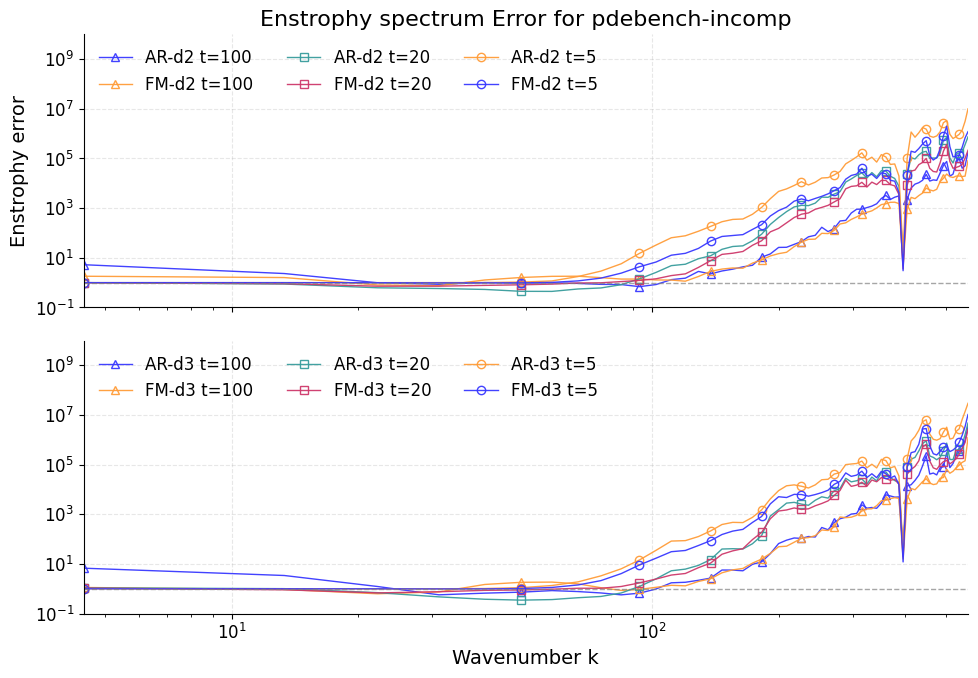

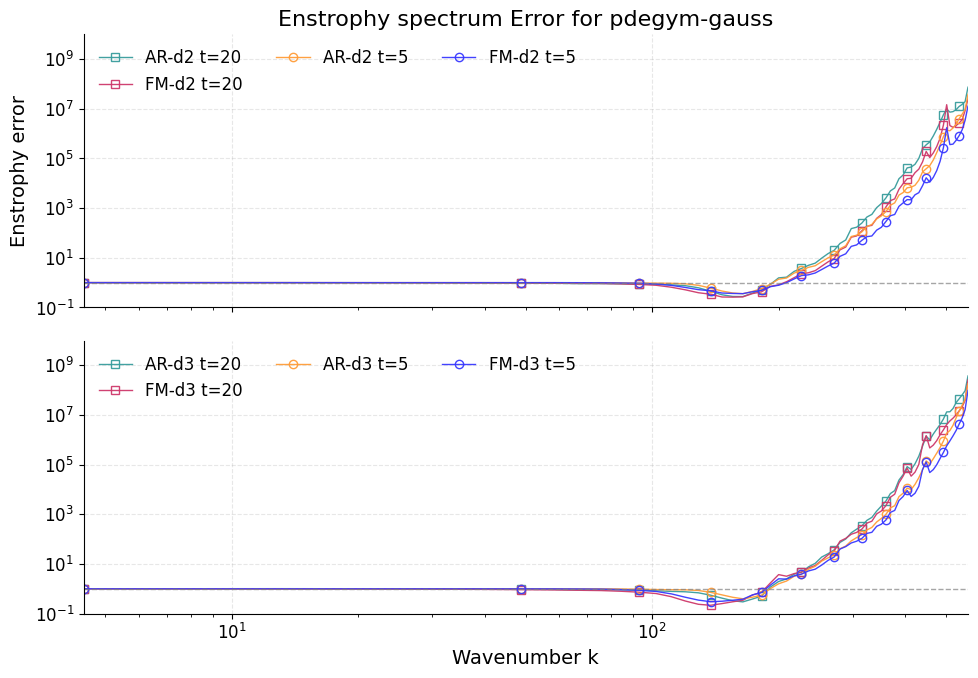

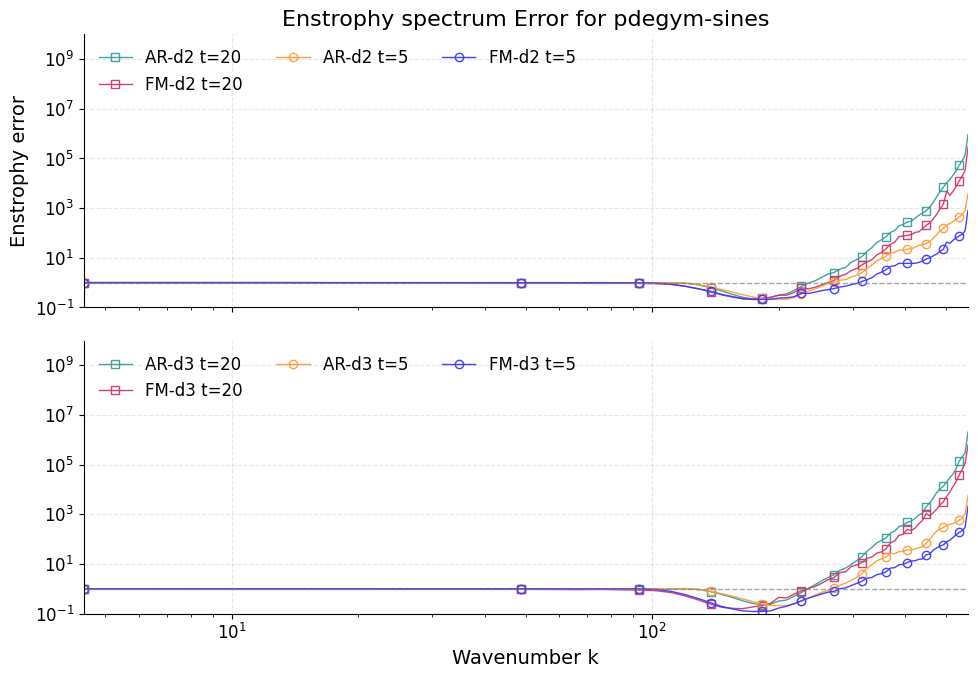

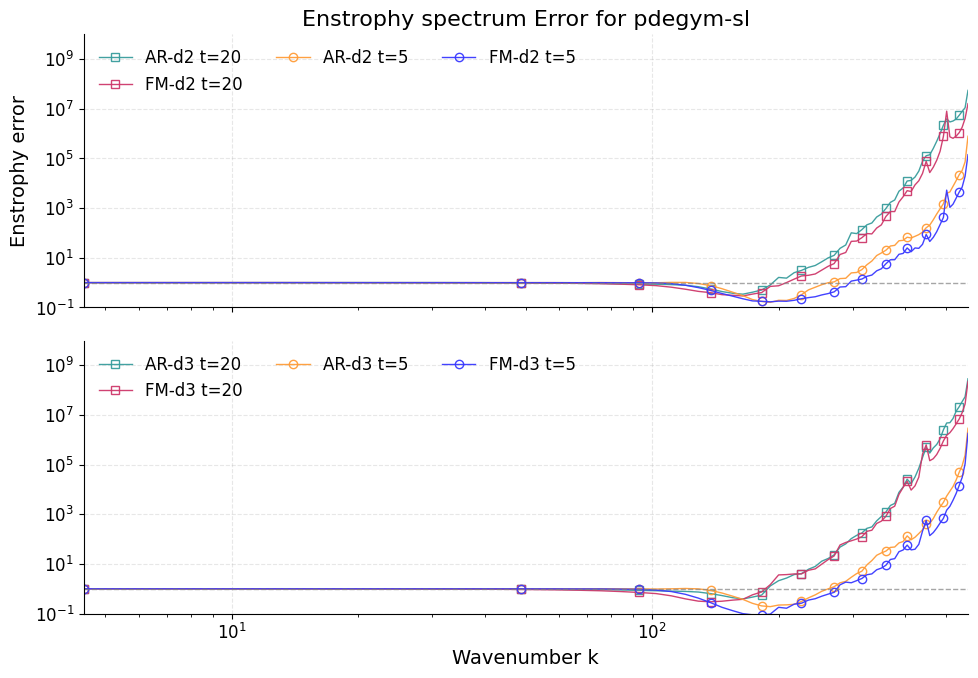

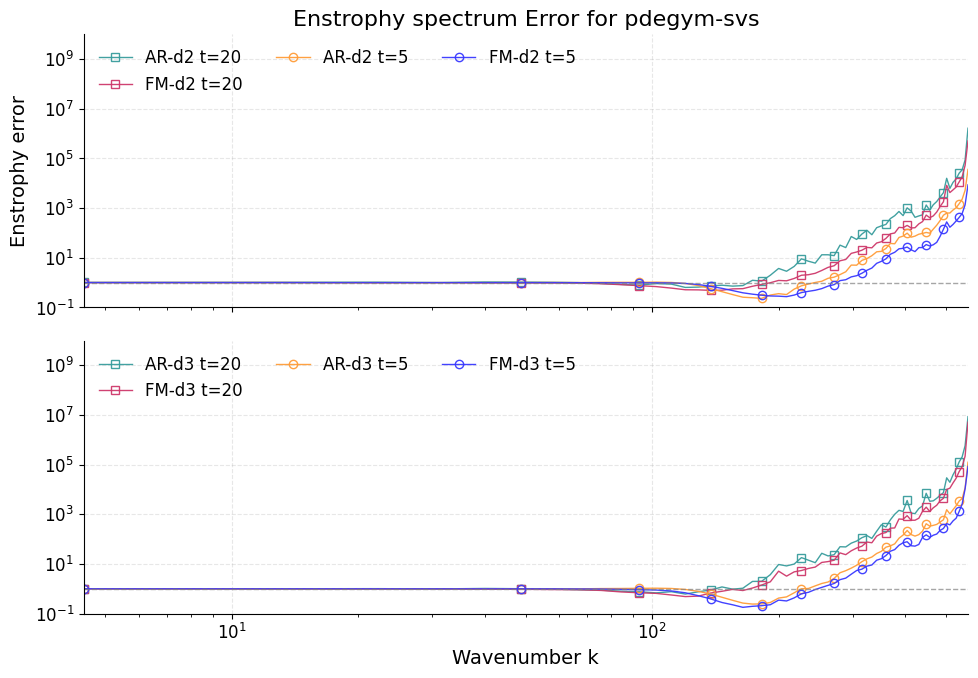

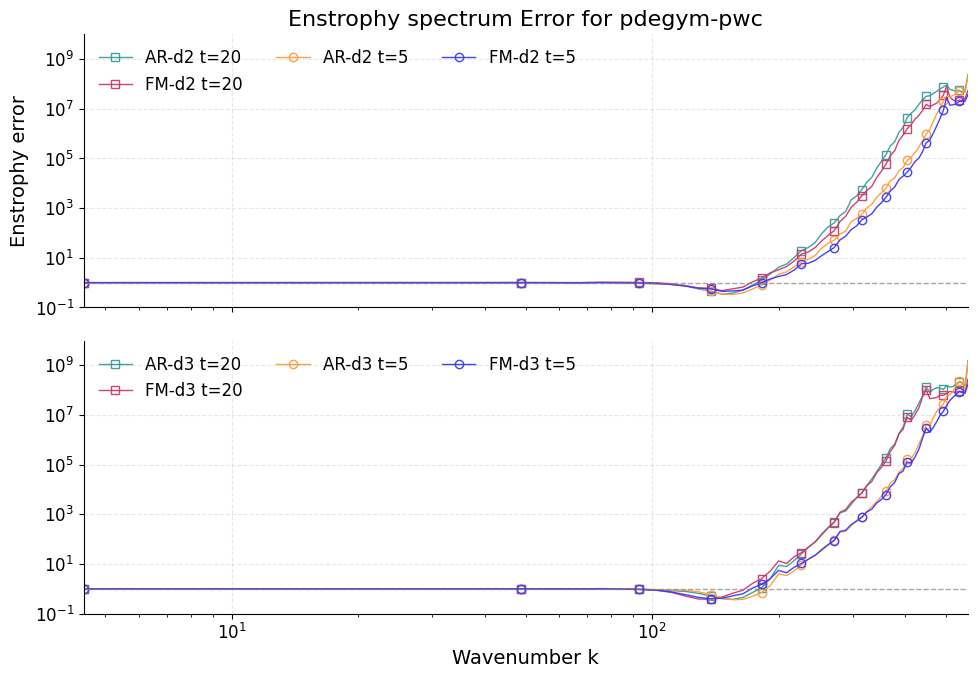

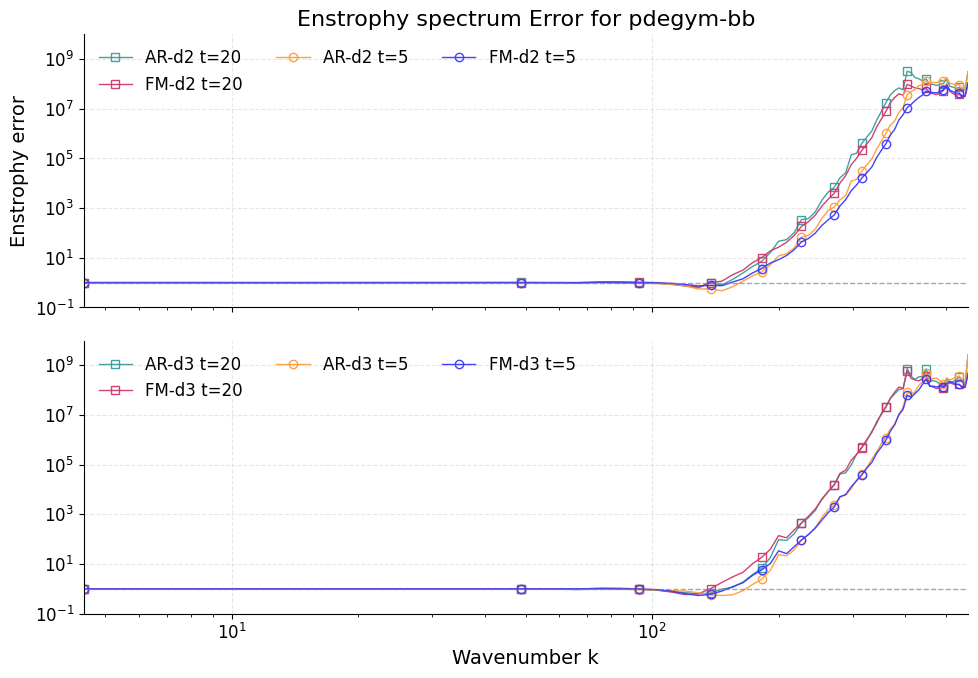

In [3]:
base_path_ar = "../../../FluidGPT_validation/final_data/MTT/ar-d2-9-last/spectra_error/"
base_path_ar2 = "../../../FluidGPT_validation/final_data/MTT/ar-d3-6-last/spectra_error/"
base_path_fm = "../../../FluidGPT_validation/final_data/FM/fm-d2-9/spectra_error/"
base_path_fm2 = "../../../FluidGPT_validation/final_data/FM/fm-d3-6/spectra_error/"
spectrum_actual = ["Energy", "Enstrophy"]
linestyles = ['-', '--', ':']
markers = ['o', 's', '^']

######################## ADJUSTMENT ON COLORS AND PRESENTATION NEEDED

for spectrum_type, spectrum_name in zip(["E", "Z"], spectrum_actual):
    for dataset_name in datasets_all:
        if dataset_name == "pdebench-comp":
            continue
        if dataset_name == "amira" or dataset_name == "pdebench-incomp":
            timestep_list = ["=5", "=20", "final"]
            if dataset_name == "amira":
                timestep_actual = ["5", "20", "200"]
            if dataset_name == "pdebench-incomp":
                timestep_actual = ["5", "20", "100"]
        else:
            timestep_list = ["=5", "=20"]
            timestep_actual = ["5", "20"]
        #timestep_list = ["=5", "=20"]
        #timestep_actual = ["5", "20"]
        k_filename = f"{base_path_ar}k_steps_{dataset_name}.json"
        #print(k_filename)
        with open(k_filename, "r") as f:
            k_steps = json.load(f)
        #print(f"k_steps length: {len(k_steps)}")
        # create figure
        fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(10, 7), sharex=True, sharey=True)
        for c, (t, timestep) in reversed(list(enumerate(zip(timestep_actual, timestep_list)))):
            
            filename_ar = f"{base_path_ar}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            filename_fm = f"{base_path_fm}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            filename_ar2 = f"{base_path_ar2}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            filename_fm2 = f"{base_path_fm2}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            
            with open(filename_ar, "r") as f:
                data_ar = np.array(json.load(f))
            with open(filename_ar2, "r") as f:
                data_ar2 = np.array(json.load(f))
            with open(filename_fm, "r") as f:
                data_fm = np.array(json.load(f))
            with open(filename_fm2, "r") as f:
                data_fm2 = np.array(json.load(f))

            #print(f"Dataset: {dataset_name}, Time step: {t}, FM shape: {data_fm.shape}, AR shape: {data_ar.shape}, FM2 shape: {data_fm2.shape}, AR2 shape: {data_ar2.shape}")
            #print(f"data_fm shape: {data_fm.shape}, data_ar shape: {data_ar.shape}")
            avg_fm = np.mean(data_fm, axis=(1,2))
            avg_fm2 = np.mean(data_fm2, axis=(1,2))
            avg_ar = np.mean(data_ar, axis=1)
            avg_ar2 = np.mean(data_ar2, axis=1)
            #print(avg_ar.shape, avg_fm.shape, avg_ar2.shape, avg_fm2.shape)
            #print(f"avg_fm shape: {avg_fm.shape}, avg_ar shape: {avg_ar.shape}")
            q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=(2))
            q0_2, q25_2, q50_2, q75_2, q100_2 = np.quantile(data_fm2, [0, 0.25, 0.5, 0.75, 1], axis=(2))
            #compute the mean of the quantiles over axis 1
            q0 = np.mean(q0, axis=1)
            q25 = np.mean(q25, axis=1)
            q50 = np.mean(q50, axis=1)
            q75 = np.mean(q75, axis=1)
            q100 = np.mean(q100, axis=1)
            q0_2 = np.mean(q0_2, axis=1)
            q25_2 = np.mean(q25_2, axis=1)
            q50_2 = np.mean(q50_2, axis=1)
            q75_2 = np.mean(q75_2, axis=1)
            q100_2 = np.mean(q100_2, axis=1)
            
            ax[0].plot(k_steps, avg_ar, label=f'AR-d2 t={t}', linewidth=1, color=colors[c], alpha=0.95, marker=markers[c], markevery=5)
            ax[0].plot(k_steps, avg_fm, label=f'FM-d2 t={t}', linewidth=1, color=colors[c+2], alpha=0.95, marker=markers[c], markevery=5)
            #ax[0].fill_between(k_steps, q25, q75, color=colors[1], alpha=0.2, label='IQR FM-d2')
            ax[1].plot(k_steps, avg_ar2, label=f'AR-d3 t={t}', linewidth=1, color=colors[c], alpha=0.95, marker=markers[c], markevery=5)
            ax[1].plot(k_steps, avg_fm2, label=f'FM-d3 t={t}', linewidth=1, color=colors[c+2], alpha=0.95, marker=markers[c], markevery=5)
            #ax[1].fill_between(k_steps, q25_2, q75_2, color=colors[3], alpha=0.2, label='IQR FM-d3')
            # if there is pdegym as string in the dataset, set the y-scale limit to 10^9
        #print()
        ax[0].set_xscale('log')
        ax[0].set_yscale('log')
        ax[1].set_xlabel("Wavenumber k")
        ax[0].set_ylabel(f"{spectrum_name} error")
        ax[0].set_title(f"{spectrum_name} spectrum Error for {dataset_name}")
        for a in ax:
            ymin, _ = a.get_ylim()
            #print(ymin)
            a.set_ylim(0.1, 10e9) 
            a.legend(ncol=3, loc='upper left')
            a.minorticks_on()
            a.hlines(y=1, xmin=k_steps[0], xmax=k_steps[-1], color='gray', linestyle='--', linewidth=1, alpha=0.7)
            a.set_xlim(k_steps[0], k_steps[-1])
        plt.tight_layout()
        plt.savefig(f"../../report/figs/results/spectra/spectrum_{spectrum_type}_{dataset_name}.png", dpi=300)
        #plt.savefig(f"../../../FluidGPT_validation/spectra/spectrum_{spectrum_type}_{dataset_name}.png", dpi=300)
        plt.show()